# What does a forecast buy a home battery, and on which tariff?

One continuous MILP, driven by a Prophet forecast, over a 10 kWh / 1.5 kW battery on
30 Ausgrid households and a full simulated year — measured against the controllers a
household could actually install, on two price signals that reward completely different
behaviour.

### The households

30 sites, one per cluster: the centroid-nearest member of each of 30 k-means clusters over
all 300 Ausgrid households. They span the consumption shapes present in the population
rather than being a convenience sample, and `hems_study.study_units()` derives them from
the clustering rather than restating a list, so the rule is executable.

### The tariff axis

| | |
|---|---|
| **AU** | Ausgrid EA025 time-of-use on `Australia/Sydney`, working-day aware, spot-linked. Energy and a standing charge; **no capacity charge**. |
| **SI** | GEN-I Dinamični under `si_samooskrba`. Energy, a standing charge, **and an excess-power charge** measured per network block against a *dogovorjena obračunska moč* that is re-agreed each month from the peaks the controller itself realised the month before. |

The contract is therefore endogenous on SI: a controller that shaves its way onto a lower
agreed power is then held to it, and one that charges at night pays for the peak it made.
`Environment.converge_agreed_power` iterates each run to that fixed point.

### The controller axis

Every controller decides one interval at a time from what it can know, and all of them are
executed on the same battery and priced by the same evaluator — they differ *only* in how a
setpoint is chosen.

| | |
|---|---|
| `no_battery` | the reference, run as an idle policy so it carries every column the others do |
| `self_consumption` | what a residential inverter ships with: soak the surplus, cover the deficit, never trade |
| `fixed_schedule`, `delayed_pv_charge` | a clock, and feed-in damping |
| `price_threshold`, `price_rank_daily`, `tariff_arbitrage` | trade on the published day-ahead price |
| `peak_shaving`, `self_consumption_peak_shaving` | watch the meter (SI only — there is no capacity charge on AU for them to earn from) |
| `price_oracle` | `price_threshold` reading forward instead of backward. **Not deployable**; it bounds what foresight is worth to a threshold rule |
| `prophet` | the MILP on a Prophet forecast — the study's subject |
| `oracle` | the same MILP on realised data: perfect foresight *within the control horizon* |
| `milp_full` | one MILP over the **whole scored year**, perfect foresight throughout. Not deployable either; it is the denominator every `gain_share_pct` divides by, and no controller above gets underneath it on the total |

### What makes the comparison fair

One battery (`align_envelope`), one environment, one settlement. The MILP used to solve its
own copy of the battery while the rules read the environment's, which differ by `eff²` — a
5.3 % larger charge rating and a 5.0 % smaller discharge rating — and the two were priced by
different functions. Both are now shared, and `Cost_EUR_Closed` values any energy left in the
pack at the end at the mean delivered import rate, so a rule that runs the battery flat in
December cannot book the difference as a saving.

In [1]:
### Imports
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import hems_study as hs
hs = importlib.reload(hs)

print(f"hems_study loaded: {len(hs.STUDY_ARMS)} arms, "
      f"{len(hs.rule_roster('SI')) + 1} controllers on SI, "
      f"{len(hs.rule_roster('AU')) + 1} on AU.")

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


hems_study loaded: 31 arms, 10 controllers on SI, 8 on AU.


## 1. Configuration

Everything the study computes lives in `hems_study.py`; this notebook configures it, reads
what it wrote and draws the figures. `RUN_SWEEP = True` recomputes the lot — hours — and by
default the notebook loads the CSVs the sweep already produced. Work is checkpointed per
(arm, household), and a checkpoint carries the configuration it was produced under, so a run
under superseded rules is dropped rather than resumed into.

In [2]:
import inspect

UNITS = hs.study_units()               # household -> the cluster it represents
ARMS = list(hs.ARM_ORDER)
RESULTS_DIR = hs.RESULTS_DIR
RUN_SWEEP = True                      # True -> recompute everything, resumable
N_SIM = 365
# Households in parallel, one process each. The sweep is len(ARMS) x len(UNITS)
# independent checkpointed runs -- printed below rather than written here, which
# is how the old hardcoded count came to be wrong. The household is the unit
# because every cache -- the forecast table, the fitted forecaster parameters
# and the forecast-blind oracle -- is keyed per household, so one worker owning
# a household means full cache reuse and no races. N_JOBS = 1 is the old serial
# behaviour.
N_JOBS = 10

# The battery, the horizons and the training window, READ FROM THE PIPELINE
# rather than typed. These were four lines of prose describing defaults that
# live in `run_pipeline_for_file` -- exactly the second source of truth the run
# count above was, and the count is the one that came out wrong. Deriving them
# means a changed default cannot be described here as the old one.
_D = {k: v.default for k, v in
      inspect.signature(hs.run_pipeline_for_file).parameters.items()}
_usable = _D["battery_cap"] * (_D["soc_max_pct"] - _D["soc_min_pct"])
_hz = sorted({a.get("control_horizon", _D["H"]) for a in hs.STUDY_ARMS},
             reverse=True)

print(f"households    : {len(UNITS)}, one per k-means cluster over all 300 Ausgrid sites")
print(f"battery       : {_D['battery_cap']:.0f} kWh nameplate, {_usable:.1f} kWh "
      f"usable (SOC {_D['soc_min_pct']:.0%}-{_D['soc_max_pct']:.0%}), "
      f"{_D['p_max']} kW AC, eff {_D['eff']}")
print(f"horizon       : "
      + ", ".join(f"{hs.horizon_label(h, _D['delta_t'])} ({h} steps)" for h in _hz)
      + f" at {_D['delta_t'] * 60:.0f}-minute resolution")
print(f"simulation    : {N_SIM} days after {_D['n_train']} days of training data")
print(f"solver        : {hs.SOLVER_NAME}"
      f"{' (in-process; no subprocess per solve)' if hs.SOLVER_NAME == 'HiGHS' else ''}")
print(f"parallelism   : {N_JOBS} worker(s) over {len(UNITS)} households")
print(f"runs          : {len(ARMS)} arms x {len(UNITS)} households "
      f"= {len(ARMS) * len(UNITS)} checkpointed runs")

print(f"\narms          : {len(ARMS)}")
for arm in hs.STUDY_ARMS:
    spec = {k: v for k, v in arm.items() if k != "name"}
    # Same overflow as the table in the next section: eleven arm names are
    # longer than 18 characters, so their specs started in a different column.
    print(f"   {arm['name']:{max(len(a) for a in hs.ARM_ORDER)}s}  {spec}")

print(f"\ncontrollers")
for tariff in ("AU", "SI"):
    names = ["no_battery"] + [p.name for p in hs.rule_roster(tariff)] + ["prophet", "oracle"]
    print(f"   {tariff}: {', '.join(names)}")

print(f"\nreference arms: {hs.REFERENCE_ARM}")
print("The two peak-shaving rules run on SI only: Ausgrid EA025 as modelled carries no")
print("capacity charge, so on AU they could only spend round-trip losses.")

households    : 30, one per k-means cluster over all 300 Ausgrid sites
battery       : 10 kWh nameplate, 7.0 kWh usable (SOC 10%-80%), 1.5 kW AC, eff 0.95
horizon       : 24 h (48 steps), 11 h (22 steps) at 30-minute resolution
simulation    : 365 days after 730 days of training data
solver        : HiGHS (in-process; no subprocess per solve)
parallelism   : 10 worker(s) over 30 households
runs          : 31 arms x 30 households = 930 checkpointed runs

arms          : 31
   AU_H24                       {'tariff': 'AU', 'control_horizon': 48}
   AU_H11                       {'tariff': 'AU', 'control_horizon': 22}
   SI_H24                       {'tariff': 'SI', 'control_horizon': 48}
   SI_H11                       {'tariff': 'SI', 'control_horizon': 22}
   AU_H24_leaked                {'tariff': 'AU', 'control_horizon': 48, 'leak_current_interval': True}
   AU_H24_persist               {'tariff': 'AU', 'control_horizon': 48, 'forecaster_kind': 'persistence'}
   SI_H24_persist         

## 2. Run or load

One checkpoint per (arm, household). Only households that finished every arm enter the
comparison, so a difference between arms is not a difference in sample.

In [3]:
if RUN_SWEEP:
    # `run_arms` now prints how many of these runs it EXECUTED and how many it
    # read back from checkpoints. Both used to be reported as "930/930 runs
    # succeeded in 1.2 min", which is the cost of reading 930 JSON files and
    # reads as a machine forty times faster than the one section 6 measured.
    _swept = hs.run_arms(
        data_dir=str(Path("..") / "Input data" / "Ausgrid"),
        output_root=str(RESULTS_DIR),
        dataset_ids=hs.dataset_ids(),
        n_sim=N_SIM,
        n_jobs=N_JOBS,
    )

df_all = hs.collect_results(RESULTS_DIR)
if df_all.empty:
    # RuntimeError, not SystemExit: IPython CATCHES SystemExit, prints almost
    # nothing and lets "Run All" carry straight on into the next cell, which
    # then fails on an undefined `long` and buries the real message under a
    # NameError. A notebook needs the traceback that stops the run.
    raise RuntimeError(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python hems_study.py  (hours, resumable), or set RUN_SWEEP = True above."
    )

# 29, not 20: six arm names are longer than that and `AU_H24_hbd_median14_pvtruth`
# is 27, so the columns to the right of them used to be pushed out of line and
# the table stopped being readable exactly where the newest arms are.
_w = max(len(a) for a in hs.ARM_ORDER) + 2
print(f"{'arm':{_w}s}{'tariff':>8s}{'households':>12s}{'with roster':>13s}")
for arm in sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index):
    sub = df_all[df_all["arm"] == arm]
    print(f"{arm:{_w}s}{str(sub['tariff'].iloc[0]):>8s}{len(sub):>12d}"
          f"{int(sub['roster_complete'].sum()):>13d}")

# A checkpoint written before the rule roster existed carries cost_prophet and
# cost_oracle but none of the rules. Reading it as though it did is how a partial
# panel gets reported as a whole one, so those rows are held out and said so.
stale = df_all[~df_all["roster_complete"]]
if len(stale):
    print(f"\nHeld out -- no rule-based controllers on these runs, so they predate the "
          f"roster and cannot be compared against it: {len(stale)} run(s) across "
          f"{', '.join(sorted(stale['arm'].unique()))}")
    print("Re-run them with RUN_SWEEP = True to bring them onto the current comparison.")
df_all = df_all[df_all["roster_complete"]].reset_index(drop=True)
if df_all.empty:
    raise RuntimeError(
        "No run carries the rule-based controllers yet, so there is nothing to compare "
        "the MILP against. Run the sweep: python hems_study.py"
    )

# A household enters only if it finished every arm still standing, so a
# difference between arms is not a difference in sample.
arms_present = sorted(df_all["arm"].unique(), key=hs.ARM_ORDER.index)
done = df_all.groupby("dataset")["arm"].nunique()
balanced = set(done[done == len(arms_present)].index)
held = set(df_all["dataset"]) - balanced
if held:
    print(f"\nHeld out to keep the panel balanced (finished some arms, not all): "
          f"{len(held)} -- {', '.join(sorted(held))}")
df_all = df_all[df_all["dataset"].isin(balanced)].reset_index(drop=True)

# A saving PERCENTAGE needs a positive baseline. A net exporter has
# cost_no_battery <= 0, and dividing by it flips the sign, so a site that saves
# money would read as one that loses it.
neg = df_all.loc[df_all["cost_no_battery"] <= 1e-9, "dataset"].unique()
if len(neg):
    print(f"\n! {len(neg)} site(s) have a non-positive no-battery cost; their euro "
          f"columns are valid but every _pct column is NaN: {', '.join(neg)}")

print(f"\nComparing {df_all['dataset'].nunique()} households across "
      f"{len(arms_present)} arms = {len(df_all)} runs.")


######################################################################
### PARALLEL SWEEP: 31 arms x 30 households = 930 runs, 10 workers
### solver HiGHS; per-household logs under /Users/summerscholl/Documents/ERK-2026/Yoann/results_local/logs/
######################################################################



[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:   24.5s


[Parallel(n_jobs=10)]: Done  15 out of  30 | elapsed:   48.1s remaining:   48.1s
[Parallel(n_jobs=10)]: Done  19 out of  30 | elapsed:   48.2s remaining:   27.9s


[Parallel(n_jobs=10)]: Done  23 out of  30 | elapsed:  1.2min remaining:   21.8s


[Parallel(n_jobs=10)]: Done  27 out of  30 | elapsed:  1.2min remaining:    8.0s



All arms: /Users/summerscholl/Documents/ERK-2026/Yoann/results_local/summary_all_arms.csv

=== 930/930 runs succeeded in 1.2 min on 10 workers ===
    930 served from checkpoints
    Nothing was executed: every run was already on disk under this configuration, so the 1.2 min above is the cost of READING 930 checkpoints, not of producing them.
    What producing them cost is `arm_runtimes`.
arm                            tariff  households  with roster
AU_H24                             AU          30           30
AU_H11                             AU          30           30
SI_H24                             SI          30           30
SI_H11                             SI          30           30
AU_H24_leaked                      AU          30           30
AU_H24_persist                     AU          30           30
SI_H24_persist                     SI          30           30
AU_H24_pvnaive                     AU          30           30
SI_H24_pvnaive                     SI  

[Parallel(n_jobs=10)]: Done  30 out of  30 | elapsed:  1.2min finished


## 3. The comparison table

`saving` is against the same household with no battery, in the arm's own currency (AUD on
AU, EUR on SI) — read percentages *down* a tariff, never across one.

`Gain_share_pct` is the share of the **whole-period optimum's** saving a controller
captured — `milp_full`, one MILP over the entire scored year with perfect foresight
throughout — measured on the quantity that solve actually minimises: bill + standing charge
+ wear. `full_period_bound_check` verifies per run that nothing beats it, and across all 930
household-arms of this sweep nothing does.

Measured on the energy bill alone (`Gain_gross_pct`) the ceiling is *not* a ceiling, and the
difference is instructive rather than cosmetic. Of the 9 270 (household, arm, controller)
rows that are neither the reference nor the optimum, **1157 clear it**, for two different
reasons, and both are the measure failing rather than a
controller winning:

* **Wear is in the optimum's objective and not in the gross measure.** `milp_full` minimises
  bill + standing charge + wear, so a rule that buys a cheaper bill with more cycles beats it
  on bill alone. This is most of the excess: `price_rank_daily` (336 household-arms),
  `price_oracle` (320), `price_threshold` (320) and `oracle` (106) — on AU the price rules
  cycle 225 times a year against the optimum's 127.
* **On SI the contract is endogenous.** `self_consumption_peak_shaving` clears it on 75,
  because the *dogovorjena moč* re-agrees from the peaks the controller itself made, so a
  peak shaver trades a larger energy bill for a smaller contract — which a measure that
  drops the standing charge cannot see.

On the total, which is what the optimum actually minimises, nothing clears it anywhere.

It used to divide by `oracle`, which is perfect foresight only *within the control horizon*
(24 h or 11 h) — a horizon-limited heuristic being called "theoretical". That reading is
kept as `gain_share_pct_vs_mpc_oracle`, because "how much of what an MPC with a perfect
forecast got" is still a real question; it is just not the one the word promised.

Costs are compared on the **total**: bill + standing charge + wear. Every MILP controller
now carries the wear price in its objective, so that total is what they are actually
minimising — and on SI the standing charge moves with the contract the controller's own
peaks agree to, so leaving it out would credit a peak shaver with nothing.

`NPV` and `IRR_pct` are the same run read over the **pack's life** instead of over the
scored year, and they change what the rest of the table means. One solved year of
`saving_total` — bill plus, on SI, the standing charge, net of wear — repeated over a 12-year
calendar life at 5 % real, against the pack priced in the arm's own currency: 3500 EUR on SI,
5691 AUD on AU (250 EUR/kWh plus a 1000 EUR install, converted at the 0.615 the AU tariff
itself uses). The cycle limit is deliberately not applied on top — wear is already subtracted
as cash — and it would not bind anyway: the hardest-cycling controller books ~225 EFC/a
against a 6000 EFC rating, which is 27 years of cycle life under a 12-year calendar band.

Every controller on both tariffs comes out **negative on both**, and that is the result rather
than a bug: at these quotes the ranking is over how far short the pack falls, not over which
one to buy. `IRR_pct` is signed and reports that shortfall as a rate. It is `NaN` — printed
`n/a` — where the saving does not cover the O&M charge, because no discount rate solves
`savings · PVF(r) = capex` when the annuity is non-positive; that is "never, at any rate",
which is a different statement from a large negative one. `IRR_n` says how many of the 30
households have a defined one, so a median IRR and a median NPV cannot silently be read over
different samples.

`NPV` and `IRR_pct` here are the **pack + install** reading, 3500 EUR / 5691 AUD. The pack
on its own — 2500 EUR / 4065 AUD, no hybrid inverter and no fitting — is `npv_pack_only` and
`irr_pct_pack_only` in `long`, and the lifetime figure below plots the two side by side. The
1000 EUR fee is worth 1133 EUR of NPV on SI and 8.1 points of IRR on the optimum, and it is
what puts several SI controllers into "no IRR exists" rather than merely "negative".

**Units.** `Cur` names the currency every money column in that row is in. Money columns are
per household-year, except `NPV`, which is over the whole 12-year life.


In [4]:
long = hs.summarize(df_all)

# One row per (arm, controller): the median household, and the spread across them.
summary = (long.groupby(["arm", "controller"])
           .agg(Households=("cost", "size"),
                Cost=("cost", "median"),
                Saving=("saving", "median"),
                Saving_pct=("saving_pct", "median"),
                # Net of wear, and on SI net of the contract the controller
                # walked itself onto: the quantity `milp_full` minimises, and so
                # the only one its 100 % is a real ceiling on. `Gain_gross_pct`
                # is the old energy-bill reading, kept because a controller that
                # scores well there and badly here is buying its bill out of
                # pack life, which is worth being able to see.
                Saving_net=("saving_net_of_wear", "median"),
                Cost_total=("cost_total", "median"),
                Gain_share_pct=("gain_share_net_pct", "median"),
                Gain_gross_pct=("gain_share_pct", "median"),
                Worst_pct=("saving_pct", "min"),
                Best_pct=("saving_pct", "max"),
                EFC=("efc", "median"),
                # Over the PACK'S LIFE rather than over the scored year, which
                # is the only horizon on which "should a household buy this"
                # has an answer. `NPV` is one solved year of `saving_total`
                # -- bill + standing charge, net of wear -- repeated over a
                # 12 y calendar life at 5 % real, against the pack priced in
                # the arm's own currency. `IRR_pct` is the rate that drives
                # that to zero, and it is signed: every controller here earns a
                # negative one, which is the result, not a bug.
                NPV=("npv", "median"),
                IRR_pct=("irr_pct", "median"),
                # HOW MANY households the IRR median is over. It is NaN where
                # the saving does not cover the O&M charge -- no discount rate
                # solves that, so there is no root to report -- and without this
                # column a median IRR and a median NPV would silently be taken
                # over different samples and could disagree.
                IRR_n=("irr_defined", "sum"))
           .reset_index())
order = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
summary = (summary.assign(Cur=summary["arm"].map(hs.currency),
                          _a=summary["arm"].map(hs.ARM_ORDER.index),
                          _c=summary["controller"].map(order))
           .sort_values(["_a", "_c"]).drop(columns=["_a", "_c"])
           .set_index(["arm", "controller"]))
# `Cur` first: it is the unit every money column below is in, and a unit read
# after the number it qualifies has already been misread once.
summary = summary[["Cur"] + [c for c in summary.columns if c != "Cur"]]

print("units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own "
      "currency (`Cur`), AUD on AU and EUR on SI, never comparable across a "
      "tariff.\n"
      "        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is "
      "over the whole 12 y life.\n"
      "        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. "
      "EFC: equivalent full cycles per year.\n"
      "        IRR_n: households of {n} with a defined IRR.".format(
          n=long["dataset"].nunique()))
summary.round(2)

units -- Cost, Saving, Saving_net, Cost_total, NPV: the arm's own currency (`Cur`), AUD on AU and EUR on SI, never comparable across a tariff.
        Cost/Saving/Saving_net/Cost_total are per household-YEAR; NPV is over the whole 12 y life.
        Saving_pct, Gain_*_pct, Worst/Best_pct, IRR_pct: per cent. EFC: equivalent full cycles per year.
        IRR_n: households of 30 with a defined IRR.


Cur  Households    Cost  \
arm                         controller                                   
AU_H24                      no_battery         AUD          30  776.31   
                            self_consumption   AUD          30  654.19   
                            fixed_schedule     AUD          30  526.56   
                            delayed_pv_charge  AUD          30  654.18   
                            price_threshold    AUD          30  489.67   
...                                            ...         ...     ...   
SI_H24_hbd_median14_pvtruth price_oracle       EUR          30  275.47   
                            tariff_arbitrage   EUR          30  288.46   
                            prophet            EUR          30  282.91   
                            oracle             EUR          30  271.62   
                            milp_full          EUR          30  268.26   

                                               Saving  Saving_pct  Saving_net  \
arm                         controller                                          
AU_H24                      no_battery           0.00        0.00        0.00   
                            self_consumption   108.67       13.47       84.43   
                            fixed_schedule     213.00       26.59      162.85   
                            delayed_pv_charge  108.65       13.46       84.42   
                            price_threshold    265.99       32.07      173.21   
...                                               ...         ...         ...   
SI_H24_hbd_median14_pvtruth price_oracle        35.05        9.76        0.01   
                            tariff_arbitrage    20.30        5.99      -56.68   
                            prophet             24.03        6.12       -3.07   
                            oracle              40.86       10.55       11.62   
                            milp_full           45.86       12.12       15.95   

                                               Cost_total  Gain_share_pct  \
arm                         controller                                      
AU_H24                      no_battery             776.31            0.00   
                            self_consumption       670.25           47.85   
                            fixed_schedule         577.01           85.20   
                            delayed_pv_charge      670.25           47.82   
                            price_threshold        576.76           87.68   
...                                                   ...             ...   
SI_H24_hbd_median14_pvtruth price_oracle           463.20            6.53   
                            tariff_arbitrage       496.84          -42.95   
                            prophet                462.86            2.59   
                            oracle                 450.03           28.34   
                            milp_full              399.75          100.00   

                                               Gain_gross_pct  Worst_pct  \
arm                         controller                                     
AU_H24                      no_battery                   0.00       0.00   
                            self_consumption            48.85       3.02   
                            fixed_schedule              86.06      13.00   
                            delayed_pv_charge           48.81       3.02   
                            price_threshold            104.83      14.06   
...                                                       ...        ...   
SI_H24_hbd_median14_pvtruth price_oracle                76.75       2.04   
                            tariff_arbitrage            51.07       1.59   
                            prophet                     53.19       1.09   
                            oracle                      87.92       2.58   
                            milp_full                  100.00       3.03   

                                       

In [5]:
### The best deployable rule on each tariff, against the MPC and against the optimum
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    winner = hs.best_rule(long, arm)
    if winner is None:
        print(f"{tariff}: no rule-based controller has run on {arm} yet.")
        continue
    tab = summary.loc[arm]
    cur = hs.currency(arm)
    print(f"{tariff}  (reference arm {arm}, money in {cur})")
    lab = hs.controller_label
    hz = next(a["control_horizon"] for a in hs.STUDY_ARMS if a["name"] == arm)
    # TOTAL, not the energy bill. The optimum minimises bill + standing charge +
    # wear, and it is only a ceiling on that: printed on `Cost` alone it comes
    # out ABOVE the best rule here and reads as a contradiction, because the
    # rule bought its cheaper bill with 225 cycles a year against the optimum's
    # 126. Both columns are shown so the trade is visible rather than confusing.
    #
    # NPV and IRR are the same run over the pack's life instead of over one
    # year. They are here rather than in a separate section because they change
    # what the rest of this block MEANS: the winner is the least bad of a set of
    # investments that all lose money at 250 EUR/kWh, and a ranking printed
    # without them reads as a purchase recommendation.
    # `n` beside the IRR for the same reason `IRR_n` is in the summary table:
    # the IRR is NaN where the saving never covers the O&M charge, so its median
    # is over a different subset of households than the NPV median next to it.
    # On SI this table prints an IRR for the winning rule over 3 households and
    # one for the optimum over 30.
    _irr_n = (long[long["arm"] == arm].groupby("controller")["irr_defined"]
              .sum().astype(int))
    _rows = ([winner, "prophet"]
             + (["milp_full"] if "milp_full" in tab.index else []))
    # Wide enough for the three names this block PRINTS -- not for every
    # controller in the frame, which would indent the numbers by the width of
    # "RBC: price threshold, full-year foresight (diagnostic)" and leave half
    # the header empty.
    _w = max(len(lab(c, hz, n_sim=N_SIM)) for c in _rows) + 2
    print(f"   {'controller':<{_w}s}{'total':>9s}{'bill':>9s}{'EFC':>7s}"
          f"{'NPV':>11s}{'IRR':>9s}{'n':>4s}")
    print(f"   {'':<{_w}s}{cur + '/a':>9s}{cur + '/a':>9s}{'1/a':>7s}"
          f"{cur:>11s}{'%/a':>9s}{'':>4s}")
    for c in _rows:
        mark = "   <- the ceiling" if c == "milp_full" else ""
        # "n/a" and not a number: an IRR does not EXIST where the saving never
        # covers the O&M charge, which is a different statement from a large
        # negative one and must not be printed as one.
        r = tab.loc[c, "IRR_pct"]
        irr_s = f"{r:9.1f}" if r == r else f"{'n/a':>9s}"
        print(f"   {lab(c, hz, n_sim=N_SIM):<{_w}s}{tab.loc[c, 'Cost_total']:9.2f}"
              f"{tab.loc[c, 'Cost']:9.2f}{tab.loc[c, 'EFC']:7.1f}"
              f"{tab.loc[c, 'NPV']:11.0f}{irr_s}{_irr_n.get(c, 0):>4d}{mark}")
    print(f"   n: households of {long[long['arm'] == arm]['dataset'].nunique()} "
          f"with a defined IRR -- the NPV beside it is over all of them.")
    print(f"   share of the optimum, on the total it minimises: "
          f"rule {tab.loc[winner, 'Gain_share_pct']:.1f} %, "
          f"MPC+Prophet {tab.loc['prophet', 'Gain_share_pct']:.1f} %")
    if tab.loc[winner, "Cost"] < tab.loc["prophet", "Cost"]:
        print("   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on")
        print("      the median household. The paired read-out below says whether")
        print("      that is significant.")
    # The lifetime read-out, stated rather than left to be inferred from a
    # column of negative numbers.
    best_npv = tab["NPV"].drop(index="no_battery", errors="ignore").max()
    n_pos = int((long[(long["arm"] == arm) & (long["controller"] != "no_battery")]
                 ["npv"] > 0).sum())
    capex = long.loc[(long["arm"] == arm) & (long["controller"] == "prophet"),
                     "capex"].median()
    print(f"   over the life: best NPV {best_npv:,.0f} {cur} on a "
          f"{capex:,.0f} {cur} pack; {n_pos} of "
          f"{int((long['arm'] == arm).sum()) - tab.loc['no_battery', 'Households']}"
          f" household-controllers reach NPV > 0.")
    print()

AU  (reference arm AU_H24, money in AUD)
   controller                              total     bill    EFC        NPV      IRR   n
                                           AUD/a    AUD/a    1/a        AUD      %/a    
   RBC: day-ahead price rank              573.58   485.77  225.3      -4882    -18.9  29
   MPC-MILP 24 h, Prophet forecast        647.99   591.06  138.5      -5692    -26.8  15
   MILP, full 365 d horizon (optimum)     553.46   508.32  127.2      -4747    -17.8  30   <- the ceiling
   n: households of 30 with a defined IRR -- the NPV beside it is over all of them.
   share of the optimum, on the total it minimises: rule 89.2 %, MPC+Prophet 47.5 %
   -> the forecast-free rule is CHEAPER than the forecast-driven MPC on
      the median household. The paired read-out below says whether
      that is significant.
   over the life: best NPV -4,747 AUD on a 5,691 AUD pack; 0 of 300 household-controllers reach NPV > 0.

SI  (reference arm SI_H24, money in EUR)
   controller   

## 4. Plots

Colour is the tariff — AU blue, SI orange — and within a tariff the controller family is a
shade of the same hue plus a marker shape, never a new colour. Every figure goes through
`Plotting_Functions`, which decides style, size and export, and writes the caption and the
provenance of each figure beside it under `Results/Figures/hems/`.

In [6]:
### Shared chart styling
import importlib
import Plotting_Functions as pf

# `import` returns whatever the kernel cached the first time. Editing
# Plotting_Functions and re-running this cell would otherwise keep the old
# module, which shows up as a TypeError about an argument that does exist.
pf = importlib.reload(pf)

# titles=False: an IEEE figure carries no title of its own -- the caption below
# it, set in the article, is the title. The text is not lost; it goes into each
# export's SOURCE.md as the caption to use.
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, finish

# What a colour MEANS is this study's semantics, so it stays here; only the
# palette itself is shared.
TARIFF_COLOR = {"AU": SERIES[0], "SI": SERIES[1]}

# What ALGORITHM produced a row, and over what horizon. The table lives in
# `hems_study` (CONTROLLER_ALGORITHM) rather than here: a label dict in a
# notebook cell is a second source of truth, and the controller it forgets is
# always the one just added. `LABEL` below is derived from it, per arm, because
# the horizon is part of an MPC controller's identity -- "MPC-MILP 24 h" and
# "MPC-MILP 11 h" are two different controllers and used to share one caption.
#
# The names that changed, and why they were wrong:
#   oracle     was "MILP, perfect foresight", which reads as the whole-year
#              optimum. It is a 24 h or 11 h receding-horizon solve on realised
#              data, and the horizon -- the entire point of the H24/H11 axis --
#              appeared nowhere in it.
#   prophet    was "MILP + Prophet"; same omission.
#   milp_full  is new, and is the thing "MILP, perfect foresight" was
#              describing: one solve, the whole scored year.
FAMILY = {c: hs.controller_family(c) for c in hs.CONTROLLER_ALGORITHM}
# Shade and marker by algorithm family, so a reader can tell an RBC row from an
# MPC row from the optimum without reading a single label.
FAMILY_SHADE = {"reference": 0.75, "RBC": 0.42, "MPC": 0.12, "MILP": 0.0}
FAMILY_MARKER = {"reference": "x", "RBC": "o", "MPC": "*", "MILP": "D"}


def make_labels(arm):
    """Controller -> display name, with this arm's horizon filled in."""
    spec = next((a for a in hs.STUDY_ARMS if a["name"] == arm), {})
    return {c: hs.controller_label(c, spec.get("control_horizon"), 0.5, N_SIM)
            for c in hs.CONTROLLER_ALGORITHM}


# The reference arms share a horizon, so one map serves the figures drawn from
# them; anything per-arm calls `make_labels(arm)` itself.
LABEL = make_labels(hs.REFERENCE_ARM["AU"])


def ctrl_color(tariff, controller):
    """Fill for one (tariff, controller): the tariff's hue, shaded by family."""
    return pf.mix(TARIFF_COLOR[tariff], "#ffffff",
                  FAMILY_SHADE[FAMILY.get(controller, "RBC")])


def ctrl_marker(controller):
    return FAMILY_MARKER[FAMILY.get(controller, "RBC")]


def place_labels(ax, items, fontsize=8.5, gap=3.0, obstacles=(),
                 leader_from=22.0, wrap=26):
    """Annotate (x, y, text[, colour]) points without letting two labels overlap.

    Thirteen controllers land in a small region of the wear/saving plane, and a
    fixed (8, 4) offset put "self-consumption", "delayed PV charge" and
    "self-consumption + peak shaving" on top of each other -- one illegible
    smear, and "fixed schedule" ran off the right edge.

    Each label tries candidate offsets in order and keeps the first that hits
    neither a marker nor an already-placed label and stays inside the axes.

    Three things make that work at thirteen labels rather than at six, which is
    where the first version ran out:

      RINGS, not a list of eighteen hand-typed offsets that stopped 30 pt from
      the marker. Nine radii out to 116 pt, sixteen directions on the wider
      ones. Ordered by radius and then by how horizontal the direction is, so a
      label still travels the shortest distance it can and prefers to sit
      beside its marker rather than above it.

      LEADER LINES past `leader_from`. Once a label is ~22 pt out it is no
      longer obviously attached to its point -- on SI, "price threshold
      (adaptive)" and "day-ahead price rank" both end up nearer a marker that is
      not theirs -- and the alternative to a leader is not a closer label, it is
      one that names the wrong dot.

      WRAPPING at `wrap` characters. Width is what binds here, not height:
      "RBC: price threshold, full-year foresight (diagnostic)" is 220 px on a
      380 px axes, so on one line it can only ever be placed by covering
      something. Over two lines it is half as wide and there are places to put
      it. `wrap=None` turns it off.

      A SCORED fallback. When nothing is free the old code dropped the label at
      a fixed (9, 4) -- straight back onto whatever was already there, and off
      the axes entirely if the point itself was outside the visible box, which
      is how the AU wear caption disappeared. It now keeps the candidate with
      the least overlap, so a crowded figure degrades into a slightly tight one
      rather than into a smear.
    """
    import textwrap
    from matplotlib.text import Text
    from matplotlib.transforms import Bbox
    fig = ax.figure
    fig.canvas.draw()                       # extents need a live renderer
    rend = fig.canvas.get_renderer()
    frame = ax.get_window_extent(rend)

    # The markers are obstacles too, not just the other labels.
    taken = list(obstacles)
    for it in items:
        px, py = ax.transData.transform((it[0], it[1]))
        taken.append(Bbox.from_bounds(px - 7, py - 7, 14, 14))

    # Nearest ring first, and within a ring the sideways directions first: a
    # name reads better beside its marker than stacked over it.
    CAND = []
    # Out to 200 pt -- 2.8 in, over half the width of these axes. It has to
    # reach: on SI five markers sit inside a 20 pt cluster and the only free
    # space is the empty bottom-right quadrant, which is 1.7 in away. Rings that
    # stopped at 116 pt could not get there, so those labels stayed in the
    # cluster and covered each other however the penalty was weighted. This is
    # what the leader lines are for.
    for r in (11, 17, 25, 34, 45, 58, 74, 94, 116, 142, 170, 200):
        n = 8 if r <= 17 else 16
        for k in range(n):
            a = 2.0 * np.pi * k / n
            CAND.append((r * np.cos(a), r * np.sin(a)))
    CAND.sort(key=lambda d: (round((d[0] ** 2 + d[1] ** 2) ** 0.5),
                             abs(d[1]) / (abs(d[0]) + abs(d[1]) + 1e-9)))

    def _clash(bb):
        """Overlapping area against everything placed, plus anything off-frame.

        Both terms are AREAS, in the same units, and the off-frame one is
        weighted rather than absolute. That balance is the whole behaviour of
        the placer, and getting it wrong is not subtle: at 40x the width of the
        box per pixel of overhang, a single pixel outside the frame scored worse
        than covering another label completely, so five of the thirteen SI names
        chose to sit on top of a neighbour instead of overhanging the spine by a
        few points. These labels are 200 px wide in a 380 px axes -- most of
        them CANNOT get clear of their marker without leaving the frame, so
        "never overhang" is not a constraint this figure can satisfy.
        """
        out = 0.0
        for o in taken:
            w = min(bb.x1, o.x1) - max(bb.x0, o.x0)
            h = min(bb.y1, o.y1) - max(bb.y0, o.y0)
            if w > 0 and h > 0:
                out += w * h
        ox = max(0.0, frame.x0 - bb.x0) + max(0.0, bb.x1 - frame.x1)
        oy = max(0.0, frame.y0 - bb.y0) + max(0.0, bb.y1 - frame.y1)
        return out + 3.0 * (ox * bb.height + oy * bb.width)

    # Longest labels first: they are the hardest to place, so they get the pick
    # of the free space instead of being left with whatever is over the edge.
    for item in sorted(items, key=lambda it: -len(it[2])):
        x, y, text = item[0], item[1], item[2]
        colour = item[3] if len(item) > 3 else INK
        if wrap:
            # break_long_words=False: a name is never split mid-word, so a label
            # that has no break point simply stays wide rather than becoming
            # unreadable.
            text = "\n".join(textwrap.wrap(text, wrap, break_long_words=False))
        # The search runs on BARE annotations, with no arrowprops. An
        # Annotation unions its arrow patch into `get_window_extent`, so a
        # candidate carrying a leader reports an extent that runs all the way
        # back to its own marker and collides with it by construction: every
        # ring past `leader_from` scored non-zero however empty the space was,
        # and the placer could only ever pick from the two innermost rings --
        # which is why extending the rings to 200 pt changed nothing at all.
        # (Measuring `Text.get_window_extent` instead is not the fix: it does
        # not resolve an offset-points position, so it scores a box that is not
        # where the label will be.) The leader is attached below, once the
        # position is settled and its own extent no longer matters.
        best = None                          # (penalty, artist, bbox, dx, dy)
        for dx, dy in CAND:
            ha = "center" if abs(dx) < 4 else ("right" if dx < 0 else "left")
            t = ax.annotate(text, xy=(x, y), xytext=(dx, dy),
                            textcoords="offset points", ha=ha, va="center",
                            color=colour, fontsize=fontsize, zorder=5)
            bb = t.get_window_extent(rend).padded(gap)
            pen = _clash(bb)
            if best is not None and pen >= best[0]:
                t.remove()                   # the one we already have is better
                continue
            if best is not None:
                # Exactly one artist per label survives the search. Overwriting
                # `best` without removing the artist it held drew the label
                # twice -- "tariff arbitrage" and the wear caption both came out
                # doubled, once at the runner-up offset and once at the winner.
                best[1].remove()
            best = (pen, t, bb, dx, dy)
            if pen <= 0.0:
                break

        _pen, t, bb, dx, dy = best
        if (dx * dx + dy * dy) ** 0.5 >= leader_from:
            t.remove()
            ha = "center" if abs(dx) < 4 else ("right" if dx < 0 else "left")
            ax.annotate(text, xy=(x, y), xytext=(dx, dy),
                        textcoords="offset points", ha=ha, va="center",
                        color=colour, fontsize=fontsize, zorder=5,
                        arrowprops=dict(arrowstyle="-", lw=0.5, color=colour,
                                        shrinkA=0.0, shrinkB=5.0))
        taken.append(bb)


SAMPLE = f"{df_all['dataset'].nunique()} households, one per k-means cluster"
print(f"Style ready: {SAMPLE}, {len(arms_present)} arms.")

Style ready: 30 households, one per k-means cluster, 31 arms.


findfont: Failed to find font weight semibold, now using 700.


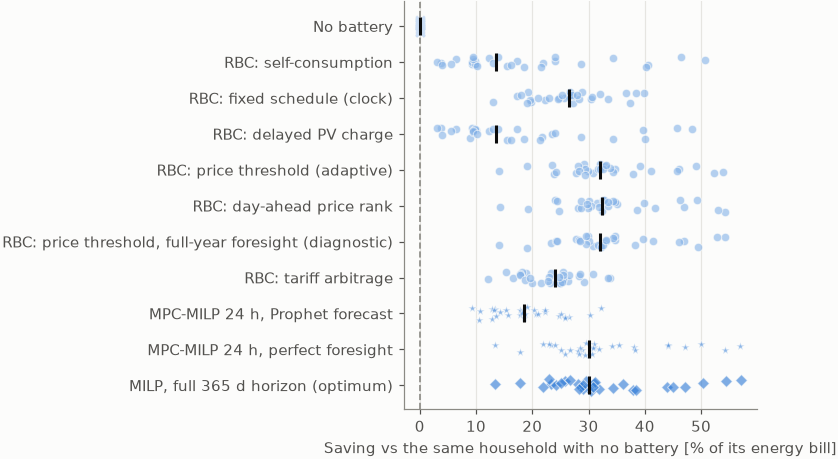

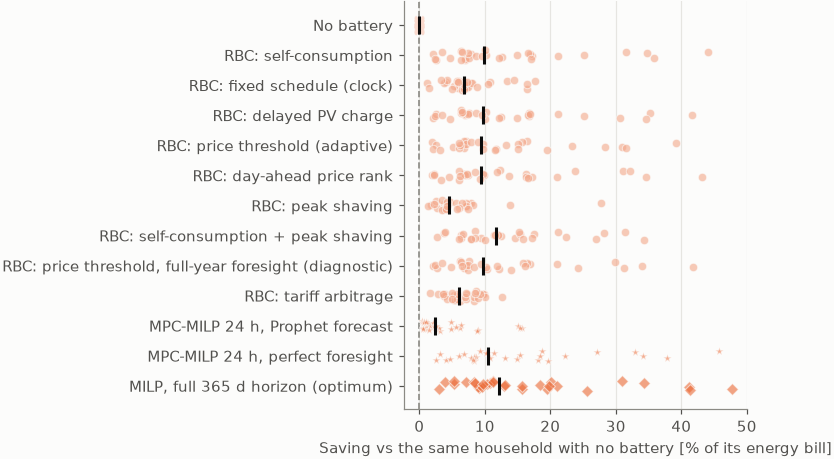

In [7]:
### Every controller on the reference arm: one dot per household, the bar is the median
# The "comparison of all" figure, one per tariff -- the tariffs reward different
# behaviour, so the winner is not assumed to be the same on both.
rng = np.random.default_rng(0)

for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    sub = long[long["arm"] == arm]
    ctrls = [c for c in hs.controller_columns(df_all) if c in set(sub["controller"])]
    ypos = np.arange(len(ctrls))[::-1]

    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    for y, c in zip(ypos, ctrls):
        vals = sub.loc[sub["controller"] == c, "saving_pct"].dropna()
        # `no_battery` draws with `x`, which HAS no face to separate from its
        # edge -- matplotlib warned on every call that it was ignoring the
        # edgecolor, once per figure. The halo is only asked for where there is
        # a fill for it to sit around.
        _halo = {} if ctrl_marker(c) in ("x", "+", "|", "_") else \
            {"edgecolor": SURFACE, "lw": 0.7}
        ax.scatter(vals, y + rng.uniform(-0.17, 0.17, len(vals)), s=30,
                   marker=ctrl_marker(c), color=ctrl_color(tariff, c),
                   alpha=0.6, zorder=3, **_halo)
        if len(vals):
            ax.scatter([vals.median()], [y], s=150, marker="|", color=INK, lw=2.0, zorder=4)
    ax.axvline(0, color=MUTED, lw=1.1, ls="--")
    ax.set_yticks(ypos, [LABEL.get(c, c) for c in ctrls])
    ax.grid(axis="y", visible=False)
    finish(ax, title=f"Every controller on {tariff}, {SAMPLE}",
           xlabel="Saving vs the same household with no battery [% of its energy bill]")
    pf.show(fig, f"controller_ranking_{tariff.lower()}")

findfont: Failed to find font weight semibold, now using 700.


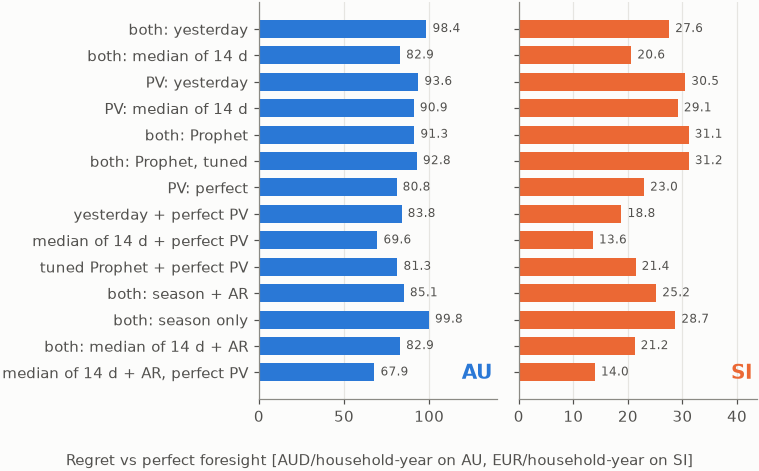

In [8]:
### What each forecast is worth: regret against perfect foresight
# A single "with forecast" arm averages the two channels into one number and
# hides which one the money is in, so the roster varies them separately. Shorter
# is better: this is the regret against a controller that sees the whole horizon.
#
# Rows are selected BY ARM, not by `forecaster_kind`. `AU_H24_leaked` carries
# kind == "prophet" exactly like `AU_H24`, so grouping by kind quietly averaged
# the current-interval look-ahead into Prophet's bar and flattered it by about
# 30 EUR. `hs.forecast_arms` reads the arm definitions and excludes it.
ARM_FOR = {t: hs.forecast_arms(t) for t in sorted(set(df_all["tariff"]))}
have = set(df_all["arm"])
kinds = [k for k in hs.FORECAST_KIND_LABELS
         if all(ARM_FOR[t].get(k) in have for t in ARM_FOR)]

if len(kinds) > 1:
    # TWO PANELS, one per tariff, each on its own x scale. AU regret runs to
    # ~150 AUD and SI to ~45 EUR; on one shared axis every SI bar would be a
    # stub. The comparison anyone reads this for is between METHODS within a
    # tariff, and faceting makes that the near comparison -- which is just as
    # well, because the two axes are not the same unit and a shared one would
    # be adding AUD to EUR.
    fig, axes = plt.subplots(1, len(ARM_FOR), figsize=pf.figsize(ratio=0.62),
                             sharey=True)
    axes = np.atleast_1d(axes)
    y = np.arange(len(kinds))[::-1]
    for ax, tariff in zip(axes, sorted(ARM_FOR)):
        # THE MEDIAN OF THE PER-HOUSEHOLD DIFFERENCES, not the difference of two
        # medians. The households are paired -- every one runs under every arm,
        # which is the whole argument of section 5 -- and a difference of
        # medians throws that pairing away: the two medians can come from
        # different households, so the result is not any household's regret.
        # It is not a rounding matter. On SI it understated Prophet's regret by
        # a third (20.6 against a paired 31.1 EUR) and on AU it reversed two
        # rows: `both: median of 14 d` read better than `PV: perfect` and is
        # not, and `both: median of 14 d + AR` read 1.8 AUD better than
        # `both: median of 14 d` when paired they are identical -- i.e. the
        # figure showed the AR stage buying something it does not buy.
        vals = [(lambda s: (s["cost_prophet"] - s["cost_oracle"]).median())
                (df_all[df_all["arm"] == ARM_FOR[tariff][k]]) for k in kinds]
        ax.barh(y, vals, height=0.68, color=TARIFF_COLOR[tariff])
        for yi, v in zip(y, vals):
            if v == v:
                # The label goes on the OUTSIDE of the bar end, whichever side
                # that is. A fixed `ha="left"` puts it inside a negative bar.
                ax.annotate(f"{v:.1f}", xy=(v, yi),
                            xytext=(4 if v >= 0 else -4, 0),
                            textcoords="offset points",
                            ha="left" if v >= 0 else "right", va="center",
                            color=INK_2, fontsize=8)
        # 1.40 rather than 1.30: the bottom bar is not the shortest one, its
        # value label lands within a character's width of the panel mark in the
        # same corner, and at 1.30 the two overlapped on AU.
        #
        # And the limits are taken from what is THERE. `max(v for v in vals if
        # v == v)` raises on an arm whose every household is NaN, and a floor
        # pinned at 0 silently clips a negative regret -- a forecast that beat
        # perfect foresight on the median household would draw as no bar at all
        # and hang its value label off the axes. Neither happens on this sweep;
        # neither is guaranteed by anything.
        _fin = [v for v in vals if v == v]
        if _fin:
            ax.set_xlim(min(0.0, min(_fin) * 1.40), max(0.0, max(_fin) * 1.40))
        if min(_fin, default=0.0) < 0:
            ax.axvline(0, color=INK, lw=1.0, zorder=3)
        ax.grid(axis="y", visible=False)
        # NOT `finish(title=...)`: `pf.use(titles=False)` lifts axes titles out
        # of the image and into the export's caption, which is right for a
        # figure title and wrong for panel identity -- it would leave two
        # unlabelled panels. This is a mark inside the axes, so it survives.
        ax.annotate(tariff, xy=(0.98, 0.04), xycoords="axes fraction",
                    ha="right", va="bottom", color=TARIFF_COLOR[tariff],
                    fontsize=13, fontweight="semibold")
    axes[0].set_yticks(y, [hs.forecast_kind_label(k) for k in kinds])
    # ONE label under the pair, not one per panel: the axes sit close enough
    # that two copies of a caption this long overlap in the middle.
    # The two panels are two CURRENCIES, so the one shared label has to name
    # both. It used to read "[EUR/household-year]" over a panel of AUD -- the AU
    # arm bills in AUD (`au_rate_vectors`), and the number under that label was
    # never euros.
    fig.supxlabel("Regret vs perfect foresight "
                  "[AUD/household-year on AU, EUR/household-year on SI]",
                  color=INK_2, fontsize=10)
    pf.show(fig, "forecast_channel_regret")
else:
    print(f"Only the {kinds} arm has run; the forecast-channel figure needs the "
          f"other forecaster arms. Run them with RUN_SWEEP = True.")


In [9]:
### Which trivial forecast is best, before spending a MILP on it
# A study arm costs a household-year of solves; a fit-free forecast costs a few
# array copies. So the roster is screened here first -- all 30 households, a
# full year each -- and only what wins is promoted to STUDY_ARMS above.
#
# The fit-free kinds take about 20 s between them. `hbd`, `hbd_baseline` and
# `hbd_median14` are NOT fit-free: each fits 48 quantile regressions per channel,
# ~170 s per household cold. That cost is only paid once, and this cell is below
# the sweep, so by the time it runs the arms above have already built and cached
# every table it needs and it is back to seconds. Running this cell on its own
# against a cold cache is the case that takes hours -- run the sweep first.
#
# `include_prophet` reads Prophet's CACHED tables (no fitting) so the model and
# the methods that need no model are scored on exactly the same days. The
# baseline of `skill` is seasonal-naive, i.e. yesterday: 0.00 means "no better
# than copying yesterday", negative means worse.
BENCH_PATH = Path(RESULTS_DIR) / "forecast_benchmark.csv"
# RESCORE WHEN THE ROSTER HAS MOVED, not only when the file is missing. The
# cached table is read whenever it exists, so a kind added to
# `hs.BENCHMARK_KINDS` after the file was written is simply absent from the
# table below -- and this is the screen that decides what gets promoted to a
# study arm, so the newest method would be the one silently missing from it,
# with nothing in the output to say so. It has already happened once, to the
# `hbd` family. Rescoring all 30 households costs about 25 s against the warm
# caches the sweep above leaves behind.
_cached = pd.read_csv(BENCH_PATH) if BENCH_PATH.exists() else None
_want = set(hs.BENCHMARK_KINDS) | {"prophet"}     # include_prophet=True below
RUN_BENCH = _cached is None or not _want <= set(_cached["kind"])
if RUN_BENCH and _cached is not None:
    print(f"Rescoring: {sorted(_want - set(_cached['kind']))} is in the roster "
          f"and not in {BENCH_PATH.name}.")

if RUN_BENCH:
    bench = hs.forecast_benchmark(
        data_dir=str(Path("..") / "Input data" / "Ausgrid"),
        dataset_ids=hs.dataset_ids(), n_sim=N_SIM, include_prophet=True)
else:
    bench = _cached
    order = [k for k in hs.FORECAST_KIND_LABELS if k in set(bench["kind"])]
    bench["kind"] = pd.Categorical(bench["kind"], categories=order, ordered=True)

print(hs.benchmark_ranking(bench).round(3).to_string())
print(f"\nnMAE is the day-ahead mean absolute error over the mean actual; skill is "
      f"1 - MAE/MAE_yesterday.")
# WHAT WINDOW these numbers are over, read from the file rather than restated
# from the cell above. A checkpoint carries the config it was produced under
# and a stale one is dropped; this CSV carried none, so the line under the
# table said "{N_SIM} simulated days" whatever the file had actually been
# scored on -- and on the cached path nothing could have contradicted it.
# `hs.provenance` names any column that disagrees, and says so plainly for a
# file written before the columns existed.
print(f"Medians over {bench['dataset'].nunique()} households.")
print(f"  scored: {hs.provenance(bench, n_sim=N_SIM)}")


                    nmae                  skill             households           
channel      consumption generation consumption generation consumption generation
kind                                                                             
persistence        0.577      0.417       0.000      0.000        30.0       30.0
weekly             0.595      0.479      -0.066     -0.148        30.0       30.0
daytype            0.585      0.437      -0.022     -0.055        30.0       30.0
mean3              0.515      0.391       0.113      0.055        30.0       30.0
mean7              0.486      0.381       0.148      0.086        30.0       30.0
median7            0.449      0.388       0.203      0.072        30.0       30.0
median14           0.450      0.373       0.218      0.112        30.0       30.0
prophet            0.631      0.488      -0.102     -0.171        30.0       30.0
hbd                0.486      0.397       0.130      0.058        30.0       30.0
hbd_baseline    

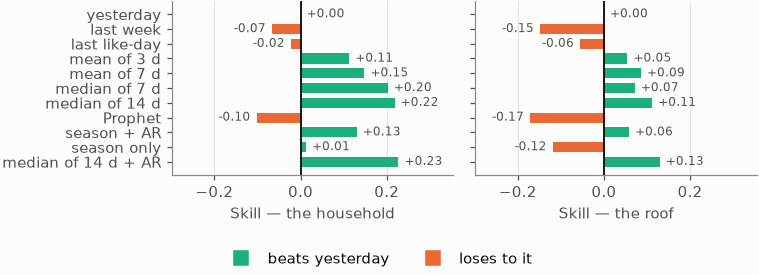

In [10]:
### Figure: what each trivial method buys against copying yesterday
# TWO PANELS, not two colours in one: the channels are different questions
# ("can you predict this roof" / "can you predict this household"), and the
# palette's two remaining hues do not separate well enough under protanopia to
# carry that on colour alone. Faceting makes the comparison within a channel --
# which is the comparison anyone reads this figure for -- the near one.
#
# Colour here encodes SIGN, and only sign: green beats yesterday, orange loses
# to it. The bar's direction from zero says the same thing, so the colour is
# never load-bearing on its own.
BEATS, LOSES = SERIES[2], SERIES[1]
med = (bench.groupby(["kind", "channel"], observed=True)["skill_vs_naive"]
            .median().unstack())
med = med.loc[[k for k in hs.FORECAST_KIND_LABELS if k in med.index]]

# One x scale across both panels. They are small multiples of the same
# measurement, so "is the roof harder than the household" has to be readable off
# the bar lengths; two scales would make every bar look the same size.
span = med.to_numpy()
lo, hi = min(span.min(), 0.0), max(span.max(), 0.0)
pad = 0.32 * (hi - lo)                      # room for the value labels

fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.42),
                         sharey=True, sharex=True)
for ax, channel, what in zip(axes, ("consumption", "generation"),
                             ("the household", "the roof")):
    vals = med[channel].to_numpy()
    y = np.arange(len(med))[::-1]           # best-known first, reading downward
    ax.barh(y, vals, height=0.68,
            color=[BEATS if v > 0 else LOSES for v in vals])
    ax.axvline(0, color=INK, lw=1.2, zorder=3)
    for yi, v in zip(y, vals):
        ax.annotate(f"{v:+.2f}", xy=(v, yi),
                    xytext=(4 if v >= 0 else -4, 0), textcoords="offset points",
                    ha="left" if v >= 0 else "right", va="center",
                    color=INK_2, fontsize=8)
    ax.set_yticks(y, [hs.FORECAST_KIND_LABELS.get(k, k).split(": ")[-1]
                      for k in med.index])
    ax.set_xlim(lo - pad, hi + pad)
    ax.grid(axis="y", visible=False)
    # In-axes, not a title: `titles=False` would lift a title out of the image
    # and the two panels would become indistinguishable.
    # Panel identity goes in the X LABEL, not a title and not an in-axes mark.
    # `pf.use(titles=False)` lifts axes titles into the export's caption, which
    # would leave two unlabelled panels; and every corner of these axes is
    # occupied by either a bar or its value label, so an annotation collides
    # with something at some data. The xlabel has reserved space of its own.
    # Short: these are half-width panels and the two labels are centred under
    # axes that meet in the middle of the figure, so at full length they abut
    # with no gap and read as one run-on line. What skill is measured against is
    # in the caption below, said once.
    finish(ax, xlabel=f"Skill \u2014 {what}")

# Skill is a RATIO and carries no unit, so what it is a ratio of has to be said
# somewhere. Three places were tried and two of them are wrong:
#
#   the x labels   the panels are half a page wide each and the labels already
#                  run edge to edge, so a scale appended to both collides in the
#                  middle.
#   a legend title `pf.key_legend(..., where="below")` anchors the legend to
#                  `axes[0]`, so a title WIDER than the legend box is centred on
#                  the left panel and starts outside the figure's left edge --
#                  which is what the committed version did, over the top of that
#                  panel's x label. Same root cause as the lifetime figure: an
#                  axes legend is the wrong object for a figure-wide key.
#   the caption    where it now is. `pf.use(titles=False)` sends the title into
#                  the export's SOURCE.md for the article to carry, which is
#                  where an IEEE figure's definitions belong; the keys keep the
#                  sign, which is the part that has to be read off the image.
#
# `chart_frame` measures the legend band in inches and lays the axes out in what
# is left, so the keys are centred on the FIGURE and nothing is squeezed. It has
# to be paired with `layout="frame"`, or `show` runs tight_layout again.
pf.chart_frame(
    fig,
    "What each trivial method buys against copying yesterday, by channel. "
    "skill = 1 \u2212 MAE / MAE_yesterday: 0 is yesterday, 1 is a forecast with "
    "no error; green beats yesterday, orange loses to it",
    handles=[plt.Line2D([], [], marker="s", ls="", ms=9, color=c, label=lab)
             for c, lab in ((BEATS, "beats yesterday"), (LOSES, "loses to it"))],
    ncol=2)
pf.show(fig, "forecast_method_skill", layout="frame")


In [11]:
### Was it just a bad Prophet? A coordinate search over its settings
# The screen above finds Prophet behind plain seasonal-naive, which is a claim
# about a CONFIGURATION rather than about the model. This is the check: one axis
# moved at a time off the module defaults, scored on the same metric under the
# same 30-day refit the arms run, so "we only tried the defaults" is not
# available as an explanation of the result.
#
# Eight households and 90 days rather than the full roster -- it is a screen, and
# the winner is validated on all 30 by the tuned ARM further down. That is why
# the skills here do not match the table above: different window, different
# subset. Read within this table, not against that one.
TUNE_PATH = Path(RESULTS_DIR) / "prophet_tuning.csv"
# Same staleness guard as the benchmark above: a config added to
# `hs.PROPHET_TUNING_GRID` after this file was written would be missing from the
# search that is supposed to have covered it, which is the one result this cell
# exists to support. Refitting is minutes and needs no MILP.
_cached_t = pd.read_csv(TUNE_PATH) if TUNE_PATH.exists() else None
RUN_TUNE = (_cached_t is None
            or not set(hs.PROPHET_TUNING_GRID) <= set(_cached_t["config"]))
if RUN_TUNE and _cached_t is not None:
    print(f"Refitting: {sorted(set(hs.PROPHET_TUNING_GRID) - set(_cached_t['config']))}"
          f" is in the grid and not in {TUNE_PATH.name}.")

if RUN_TUNE:
    tuning = hs.tune_prophet(str(Path("..") / "Input data" / "Ausgrid"),
                             n_sim=90, n_jobs=8)
else:
    tuning = _cached_t
    order = [c for c in hs.PROPHET_TUNING_GRID if c in set(tuning["config"])]
    tuning["config"] = pd.Categorical(tuning["config"], categories=order,
                                      ordered=True)

print(hs.tuning_ranking(tuning).round(3).to_string())
# Same provenance check as the benchmark above, and it matters more here: this
# screen deliberately uses a SHORTER window and FEWER households than the arms
# do, so it is the table a reader is most likely to compare against the wrong
# sample. The comment above says 8 households and 90 days; this prints what the
# file was actually scored on.
print(f"\nScreened over {tuning['dataset'].nunique()} households.")
print(f"  scored: {hs.provenance(tuning, n_sim=90)}")
print(f"\nThe study's tuned arms carry:\n  consumption {hs.TUNED_PARAMS_CON}"
      f"\n  generation  {hs.TUNED_PARAMS_GEN}")
print("Both say the same thing: the trend term was the problem. A household has "
      "no trend\nover a month, so the freedom to fit one is variance the forecast "
      "never earns back.")


                   nmae                  skill           
channel     consumption generation consumption generation
config                                                   
default           0.765      0.475       0.002     -0.436
cps_0.001         0.656      0.437       0.010     -0.350
cps_0.01          0.727      0.473      -0.029     -0.420
cps_0.5           0.802      0.476      -0.172     -0.438
flat_trend        0.708      0.426      -0.097     -0.307
sps_0.1           0.767      0.475       0.002     -0.443
sps_1             0.765      0.475       0.002     -0.437
no_yearly         0.768      0.502      -0.130     -0.515
mode_flip         0.797      0.433      -0.166     -0.341
weekly_flip       0.768      0.476       0.002     -0.437

Screened over 8 households.
  scored: n_sim=90, n_train=730, steps_per_day=48, start_ts=2010-07-01 00:30:00, refit_every_days=30

The study's tuned arms carry:
  consumption {'changepoint_prior_scale': 0.001}
  generation  {'growth': 'flat'}
Bot

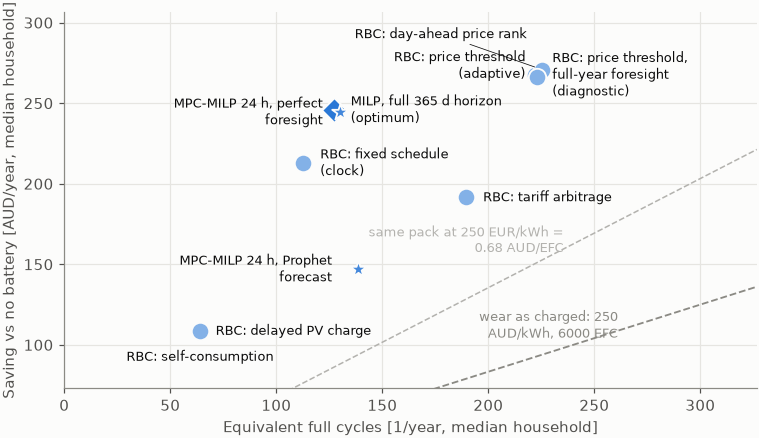

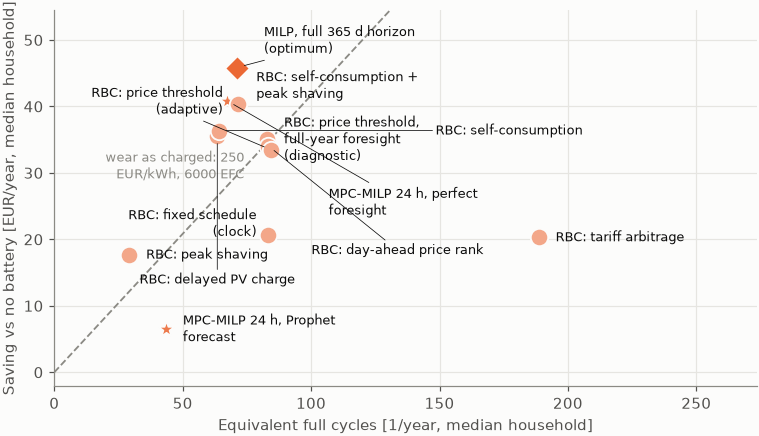

In [12]:
### Cycles against saving: what a saving costs in pack life
# A controller high on the y axis and far right on the x axis is buying its
# saving out of the battery, not out of the tariff.
#
# THE WEAR LINE IS READ FROM THE RUN, not retyped. It used to be a hard-coded
# `be.cycle_cost_eur_per_efc(10.0)` -- 0.417 -- drawn on both panels and
# captioned "250 EUR/kWh" on both. The SLOPE was what the sweep charged; the
# CAPTION named a currency the axis is not in. The AU arm bills in AUD
# (`au_rate_vectors` divides the spot series by 0.615), so this y axis is AUD,
# and 0.417 AUD/EFC is 250 AUD/kWh over 6000 cycles -- not 250 EUR/kWh, which
# on this axis is 0.678 AUD/EFC, 63 % steeper.
#
# Which of the two is the honest line depends on what the figure is for, so both
# are drawn:
#
#   solid   0.4167 per EFC in the ARM'S OWN currency -- what the sweep actually
#           charged. `wear_objective_terms` put this number in every MILP
#           objective on both arms without converting it, and `wear_eur`,
#           `Saving_net` and `Cost_total` are all computed at it. It is
#           therefore 250 AUD/kWh on AU, not 250 EUR/kWh, and drawing anything
#           else here would put the figure at odds with the table.
#   faint   the same pack at 250 EUR/kWh, converted at the tariff's own 0.615.
#           Only on AU; on SI the two coincide exactly. It is the sensitivity
#           check on the caption that was wrong, and the AU reading survives it:
#           the faint line is 1.63x steeper and no AU controller is under either
#           of them -- the closest, `tariff_arbitrage`, saves 192 AUD against
#           129 AUD of wear at the steeper rate. On SI, where there is only one
#           line, five controllers ARE under it, which is the figure doing its
#           job rather than a discrepancy between the two panels.
import Battery_Economics as be

CAP_KWH = float(df_all["battery_cap"].median())

for tariff, arm in hs.REFERENCE_ARM.items():
    sub = long[(long["arm"] == arm) & (long["controller"] != "no_battery")]
    if sub.empty or sub["efc"].isna().all():
        continue
    med = sub.groupby("controller").agg(efc=("efc", "median"),
                                        saving=("saving", "median")).dropna()
    cur = hs.currency(arm)

    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.58))
    for c, row in med.iterrows():
        ax.scatter([row["efc"]], [row["saving"]], s=130, marker=ctrl_marker(c),
                   color=ctrl_color(tariff, c), edgecolor=SURFACE, lw=1.2, zorder=3)
    # Limits BEFORE the labels: placement is measured in display space, so the
    # axes have to be their final size or every extent is computed against a
    # frame that then moves.
    # Headroom is what the labels are placed INTO. Thirteen names 200 px wide
    # in a 380 px axes have nowhere to go at 1.30/0.16, and `place_labels` then
    # spends its budget on overhang instead of on separation.
    ax.set_xlim(0, med["efc"].max() * 1.45)
    _pad = (med["saving"].max() - med["saving"].min()) * 0.22 or 1.0
    ax.set_ylim(med["saving"].min() - _pad, med["saving"].max() + _pad)
    _pts = [(r["efc"], r["saving"], LABEL.get(c, c)) for c, r in med.iterrows()]

    # What the cycles on the x axis cost. Taken from the frame -- wear per EFC
    # is `wear_eur / efc` on every row -- so a sweep solved at another pack
    # price moves this line with it instead of being drawn against a constant
    # nobody re-ran.
    _rate = (sub["wear_eur"] / sub["efc"]).replace([np.inf, -np.inf], np.nan)
    _slope = float(_rate.dropna().median())
    # And the same pack quoted in EUR, put into this arm's money.
    _slope_eur_quote = (be.cycle_cost_eur_per_efc(CAP_KWH)
                        * hs.ARM_CURRENCY_PER_EUR[tariff])

    # The y axis is scaled to the DATA, not to these lines: at 0.417 per EFC the
    # line reaches ~104 by 250 cycles while no controller saves more than ~45 on
    # SI, and letting it set the limits squashed every marker into the bottom
    # third. So they are drawn across the visible box and labelled where they
    # LEAVE it, rather than at an endpoint that is off-screen.
    _x0, _x1 = ax.get_xlim(); _y0, _y1 = ax.get_ylim()
    _per_kwh = _slope * be.BATTERY_CYCLE_LIMIT_EFC / CAP_KWH
    _lines = [(_slope, MUTED, 1.2,
               f"wear as charged: {_per_kwh:.0f} {cur}/kWh, "
               f"{be.BATTERY_CYCLE_LIMIT_EFC:.0f} EFC")]
    # On SI the quoted line IS the charged one -- the arm bills in EUR and the
    # quote is in EUR -- so drawing it would put two captions on one line.
    if abs(_slope_eur_quote - _slope) > 1e-9:
        _lines.append((_slope_eur_quote, pf.mix(MUTED, SURFACE, 0.35), 1.0,
                       f"same pack at {be.CAPEX_EUR_PER_KWH:.0f} EUR/kWh = "
                       f"{_slope_eur_quote:.2f} {cur}/EFC"))
    for _s, _c, _lw, _txt in _lines:
        xs = np.linspace(max(_x0, 0.0), _x1, 50)
        ax.plot(xs, xs * _s, color=_c, lw=_lw, ls="--", zorder=2)
        # The caption goes through `place_labels` with everything else rather
        # than carrying a hand-picked offset. A horizontal caption beside a
        # sloped line crosses it at some point on some tariff -- fixed offsets
        # put it outside the right spine on AU and on top of the line on SI --
        # and the placer already knows where the markers and the other names are.
        #
        # Anchored on the VISIBLE segment of the line, not on 62 % of the way to
        # where it exits the top. The y axis is scaled to the data and its floor
        # is well above zero on AU, so the line ENTERS the box at x = y0/s and
        # everything to the left of that is off the bottom -- the old anchor
        # landed there, `place_labels` could not fit a label inside the frame,
        # and the AU caption fell through to the fallback offset and drew itself
        # off the axes. It was not a missing label; it was a label at a point
        # that is not on the page.
        _in_lo = max(_x0, 0.0, _y0 / _s) if _s > 0 else max(_x0, 0.0)
        _in_hi = min(_x1, _y1 / _s) if _s > 0 else _x1
        _xa = _in_lo + 0.62 * max(_in_hi - _in_lo, 0.0)
        _pts.append((_xa, _xa * _s, _txt, _c))

    place_labels(ax, _pts)
    finish(ax, title=f"What a saving costs in pack life, {tariff}",
           xlabel="Equivalent full cycles [1/year, median household]",
           ylabel=f"Saving vs no battery [{cur}/year, median household]")
    pf.show(fig, f"wear_vs_saving_{tariff.lower()}")

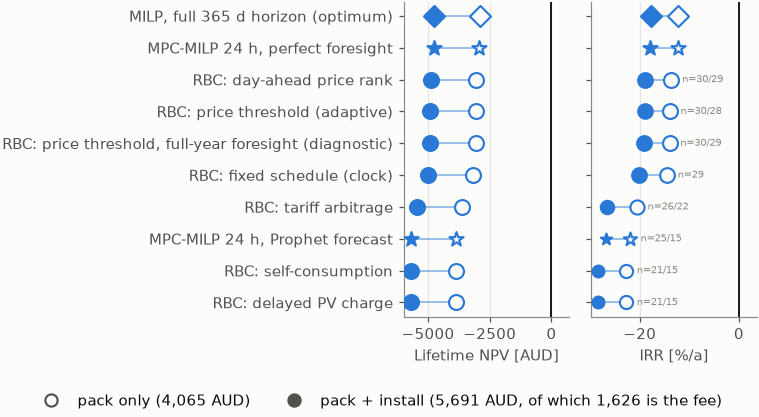

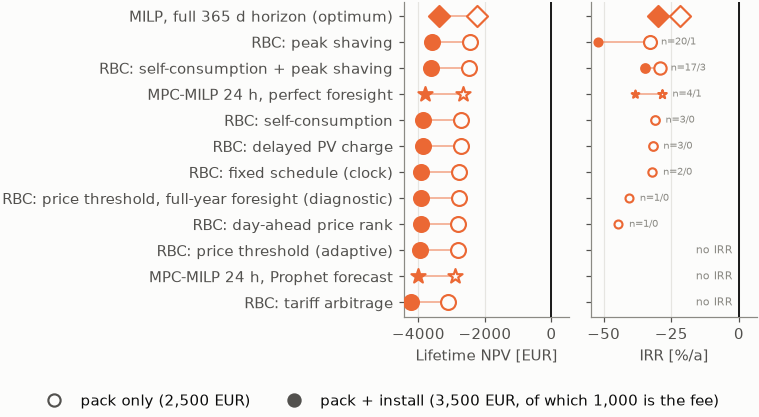

AU (AUD) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                           net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: day-ahead price rank                 176.6     -3040    -13.6  30     -4882    -18.9  29
   MPC-MILP 24 h, Prophet forecast            85.2     -3850    -22.0  25     -5692    -26.8  15
   MILP, full 365 d horizon (optimum)        191.9     -2905    -12.3  30     -4747    -17.8  30
   n: households of 30 with a defined IRR. `n/a` is "no rate solves it", not a large negative one.
   the 1,626 AUD install alone costs 1,842 AUD of NPV and 5.5 points of IRR on MILP, full 365 d horizon (optimum).

SI (EUR) -- median household, 12 y at 5% real, O&M 1.5%/a of installed capital
   controller                             net saving  NPV pack IRR pack   n  NPV +fee IRR +fee   n
   RBC: self-consumption + peak shaving         40.1     -2477    -29.2  17     -3610    -34.6   3
   MPC-MILP 24 h, Prophet forecast       

In [13]:
### What the battery is actually worth: lifetime NPV and IRR, and what the install fee costs
# The question every figure above dodges. `saving` and `gain_share_pct` rank
# controllers against each other on one year; NOTHING there says whether the box
# is worth buying, and a ranking of positive-looking savings reads like a
# purchase recommendation. This is the same runs discounted over the pack's life
# against what the pack costs, and the answer is that every marker is to the
# LEFT of the break-even line on both tariffs.
#
# TWO PANELS, not one axis with two scales. NPV is money and IRR is a rate; a
# dual axis would let the reader compare a EUR against a per cent and read a
# crossing that is an artefact of two arbitrary scalings.
#
# TWO MARKS PER ROW -- the "separate consideration" of the 1000 EUR install:
#
#   hollow   pack only, 2500 EUR of cells (4065 AUD). "Is storage worth what
#            storage costs?"
#   solid    pack + 1000 EUR hybrid inverter and fitting, 3500 EUR (5691 AUD).
#            What the household actually pays.
#
# The gap between them is what the fee is worth over the life, and it is not a
# detail: on SI it is 29 % of the capital, it does not scale with pack size, and
# because O&M is charged as a share of installed capital it drags 15 EUR/a
# behind it -- more than several SI controllers save in total. It decides
# whether a controller has an IRR at all rather than only how bad one is: on SI,
# `self_consumption` has one on 0 of 30 households with the fee in and on 3 of
# 30 without it, and `peak_shaving` goes from 1 to 20.
#
# Colour still means the tariff, and marker SHAPE still means the controller
# family, exactly as everywhere else -- the scenario is carried by fill and by
# position on its own row, so nothing here is encoded on colour alone and no new
# hue enters the palette.
import Battery_Economics as be
from matplotlib.lines import Line2D

# The middle element is the scenario's name. It is quoted per arm where it is
# drawn, because the fee is 1000 EUR on SI and 1626 AUD on AU and a label with
# "1000 EUR" in it beside a 5,691 AUD total is two currencies in one key.
ECON = [("_pack_only", "pack only", False), ("", "pack + install", True)]

for tariff, arm in hs.REFERENCE_ARM.items():
    sub = long[(long["arm"] == arm) & (long["controller"] != "no_battery")]
    if sub.empty or sub["npv"].isna().all():
        continue
    cur = hs.currency(arm)
    med = sub.groupby("controller")[
        ["npv", "npv_pack_only", "irr_pct", "irr_pct_pack_only",
         "capex", "capex_pack_only"]].median()
    # Best first, reading downward, on the reading the household pays for.
    med = med.sort_values("npv", ascending=False)
    ypos = np.arange(len(med))[::-1]
    base = ctrl_color(tariff, "milp_full")          # the tariff's own hue

    # HOW MANY HOUSEHOLDS EACH IRR MARKER IS A MEDIAN OVER. `median()` takes
    # each column independently and pandas drops NaN first, and an IRR is NaN
    # wherever the saving never covers the O&M charge -- so on SI the IRR panel
    # was plotting `milp_full` over 30 households, `self_consumption_peak_shaving`
    # over 3 and `peak_shaving` over ONE, at the same size, on one axis, with
    # nothing in the image to say so. `peak_shaving` then sat far left of
    # `self_consumption_peak_shaving` and read as "much worse" when it is one
    # outlier household against three. The NPV on the same row is always over
    # all 30, so the two numbers on one row are medians over different samples;
    # the marker area and the `n` beside the row are what makes that visible.
    #
    # The note in `summarize`'s `irr_defined` and the `IRR_n` column in the
    # summary table say the same thing in numbers. This is the figure catching
    # up with them.
    nrs = sub.groupby("controller")[["irr_defined_pack_only",
                                     "irr_defined"]].sum().astype(int)
    n_hh = sub["dataset"].nunique()

    def _area(n):
        """Marker area for a median over `n` of `n_hh` households.

        Linear in n rather than in sqrt(n): this is not a quantity anyone reads
        off the marker, it is a warning that the marker is thin, and the read
        that has to survive is "that one is smaller than the others".
        """
        return 25.0 + 70.0 * (n / n_hh)

    fig, axes = plt.subplots(1, 2, figsize=pf.figsize(ratio=0.60), sharey=True)
    for ax, (col, unit) in zip(
            axes,
            # SHORT ENOUGH FOR A HALF-WIDTH PANEL. These are two axes side by
            # side, each about 300 px of drawable width once the controller
            # names have taken the left margin, and a label of 46 characters
            # centred under each of them overprints its neighbour in the middle
            # of the figure. Which sample each median is over is the caption's
            # job -- `chart_frame` below states it -- and the `n=` marks carry
            # the per-row version.
            [("npv", f"Lifetime NPV [{cur}]"),
             ("irr_pct", "IRR [%/a]")]):
        for y, c in zip(ypos, med.index):
            xs = [med.loc[c, col + suf] for suf, _, _ in ECON]
            ns = [nrs.loc[c, "irr_defined" + suf] if col == "irr_pct" else n_hh
                  for suf, _, _ in ECON]
            if all(v == v for v in xs):
                ax.plot(xs, [y, y], color=base, lw=1.1, zorder=2, alpha=0.55)
            for x, n, (suf, _, solid) in zip(xs, ns, ECON):
                if x != x:
                    continue
                ax.scatter([x], [y], s=_area(n), marker=ctrl_marker(c), zorder=3,
                           color=base if solid else SURFACE,
                           edgecolor=base, lw=1.4)
            # The count in words as well as in area, because area alone does not
            # distinguish 30 from 26 and must not be asked to. Printed once per
            # row, to the right of the rightmost mark, as pack-only/with-fee in
            # the legend's own left-to-right order -- and only where it is not
            # the full sample, so the rows that ARE over everything stay clean.
            if col == "irr_pct" and any(n < n_hh for n in ns):
                _fin = [x for x in xs if x == x]
                if _fin:
                    ax.annotate("n=" + "/".join(str(n) for n in dict.fromkeys(ns)),
                                xy=(max(_fin), y), xytext=(7, 0),
                                textcoords="offset points", ha="left",
                                va="center", color=MUTED, fontsize=6.5)
        # An IRR that does not EXIST is not a bad IRR, and leaving the row blank
        # would read as a missing run. Said in words, on the row it belongs to.
        #
        # ONLY where the row is empty. A row with one mark left carries its
        # count beside that mark already -- `n=17/0` is the same statement as
        # "no IRR with the fee" and is in the same units as every other row --
        # and running both put the note, the mark and the count on top of each
        # other in the middle of the panel.
        if col == "irr_pct":
            for y, c in zip(ypos, med.index):
                if all(med.loc[c, "irr_pct" + suf] != med.loc[c, "irr_pct" + suf]
                       for suf, _, _ in ECON):
                    # Immediately left of the zero line: every IRR on this
                    # figure is under -12 %/a, so that strip is empty on every
                    # row, and the note sits where the number would have been.
                    ax.annotate("no IRR", xy=(0, y), xytext=(-4, 0),
                                textcoords="offset points",
                                ha="right", va="center", color=MUTED, fontsize=7.5)
        # Break-even is the reading this whole figure exists for, so it is a
        # solid rule rather than a gridline -- and it is named in the TITLE,
        # which `titles=False` lifts into the caption. Not in the axes: zero is
        # hard against the right spine (nothing is to the right of it, because
        # nothing pays), the top row is the one closest to it, and the bottom
        # row on the IRR panel already carries a "no IRR" note. Not in the x
        # labels either -- these are half-width panels and two labels long
        # enough to carry it collide in the middle, which is the same trap the
        # forecast-skill figure fell into.
        ax.axvline(0, color=INK, lw=1.2, zorder=4)
        ax.grid(axis="y", visible=False)
        # The `n=` labels hang off the right of their markers, and the topmost
        # IRR markers are within a few points of zero, so the box is widened
        # rather than letting a count run under the break-even rule.
        _l, _r = ax.get_xlim()
        ax.set_xlim(_l, _r + 0.07 * (_r - _l))
        finish(ax, xlabel=unit)

    axes[0].set_yticks(ypos, [LABEL.get(c, c) for c in med.index])
    # Two series, so a legend is not optional. Shapes are neutral here: in this
    # figure the shape is the controller's family, and what the key explains is
    # the FILL.
    #
    # ON THE FIGURE, NOT ON `axes[0]`. `pf.key_legend(..., where="below")` hangs
    # the keys off ONE axes at `bbox_to_anchor=(0.5, -0.16)`, and `pf.show`'s
    # `tight_layout` then shrinks that axes until its decorations fit. With two
    # keys this wide under a half-width panel there is no width at which they
    # do: matplotlib gave up with "tight_layout cannot make Axes width small
    # enough", both panels came out about 20 px wide with every marker on one
    # vertical line, and the two surviving x ticks overprinted into "-5000".
    # `pf.chart_frame` measures the header and legend bands in inches and hands
    # `tight_layout` a rect that excludes them, which is the same legend at full
    # figure width -- and it MUST be paired with `layout="frame"` below, or
    # `show` lays the figure out again and takes the reserved bands back.
    _fee = med["capex"].iloc[0] - med["capex_pack_only"].iloc[0]
    pf.chart_frame(
        fig,
        f"What the battery is worth over its life, {tariff}. The black rule is "
        f"break-even and every controller is to the left of it. NPV is over all "
        f"{n_hh} households; an IRR exists only where the saving covers the O&M "
        f"charge, so the IRR panel's marker area and the n beside a row are the "
        f"households behind it (pack only / with the fee)",
        # The fee is quoted in the ARM'S currency, like everything else on the
        # figure: "1000 EUR install" beside a 5,691 AUD total is two currencies
        # in one key.
        handles=[
            Line2D([], [], marker="o", ls="", ms=8, color=SURFACE,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack only ({med['capex_pack_only'].iloc[0]:,.0f} {cur})"),
            Line2D([], [], marker="o", ls="", ms=8, color=INK_2,
                   markeredgecolor=INK_2, markeredgewidth=1.4,
                   label=f"pack + install ({med['capex'].iloc[0]:,.0f} {cur}, "
                         f"of which {_fee:,.0f} is the fee)")],
        ncol=2)
    pf.show(fig, f"lifetime_economics_{tariff.lower()}", layout="frame")

# The same thing in numbers, for the three controllers the text names.
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    cur = hs.currency(arm)
    _sub = long[long["arm"] == arm]
    tab = _sub.groupby("controller").median(numeric_only=True)
    # HOW MANY households each IRR median is over, exactly as `IRR_n` does in
    # the summary table. An IRR is NaN where the saving never covers the O&M
    # charge, and pandas drops those before taking a median -- so on SI
    # `peak_shaving` reports -52 %/a from ONE household while `milp_full`
    # reports -29.9 from thirty, and printed side by side with no n they read as
    # a ranking. The NPV beside them is always over all 30, which is the other
    # half of the trap: without these columns the two numbers on one row are
    # medians over different samples.
    nrs = _sub.groupby("controller")[["irr_defined", "irr_defined_pack_only"]].sum()
    _n_hh = _sub["dataset"].nunique()
    picks = [c for c in (hs.best_rule(long, arm), "prophet", "milp_full")
             if c in tab.index]
    # Wide enough for the three names PRINTED, not for every controller in the
    # frame. "RBC: self-consumption + peak shaving" is 36 characters and was
    # being truncated to "RBC: self-consumption + peak shavi" at 34.
    _w = max(len(LABEL.get(c, c)) for c in picks) + 2
    print(f"{tariff} ({cur}) -- median household, 12 y at "
          f"{be.DISCOUNT_RATE:.0%} real, O&M {be.OPEX_FRAC_OF_CAPEX_PER_YEAR:.1%}/a "
          f"of installed capital")
    print(f"   {'controller':<{_w}s}{'net saving':>11s}"
          f"{'NPV pack':>10s}{'IRR pack':>9s}{'n':>4s}"
          f"{'NPV +fee':>10s}{'IRR +fee':>9s}{'n':>4s}")
    for c in picks:
        def _r(v):
            return f"{v:9.1f}" if v == v else f"{'n/a':>9s}"
        print(f"   {LABEL.get(c, c):<{_w}s}{tab.loc[c, 'saving_annual_net']:11.1f}"
              f"{tab.loc[c, 'npv_pack_only']:10.0f}"
              f"{_r(tab.loc[c, 'irr_pct_pack_only'])}"
              f"{int(nrs.loc[c, 'irr_defined_pack_only']):>4d}"
              f"{tab.loc[c, 'npv']:10.0f}{_r(tab.loc[c, 'irr_pct'])}"
              f"{int(nrs.loc[c, 'irr_defined']):>4d}")
    print(f"   n: households of {_n_hh} with a defined IRR. `n/a` is "
          f"\"no rate solves it\", not a large negative one.")
    # The fee IN THIS ARM'S CURRENCY, and named by the controller it is measured
    # on rather than by position. `picks[-1]` is `milp_full` only while
    # `milp_full` is in the frame; when it is not, this sentence used to go on
    # calling whatever ended up last "the optimum".
    _on = picks[-1]
    _fee = tab.loc[_on, "capex"] - tab.loc[_on, "capex_pack_only"]
    print(f"   the {_fee:,.0f} {cur} install alone costs "
          f"{tab.loc[_on, 'npv_pack_only'] - tab.loc[_on, 'npv']:,.0f} "
          f"{cur} of NPV and "
          f"{tab.loc[_on, 'irr_pct_pack_only'] - tab.loc[_on, 'irr_pct']:.1f}"
          f" points of IRR on {LABEL.get(_on, _on)}.\n")

## 5. Read-out

The households are **paired** — every one is run under every arm — so the per-site
difference is the unit of analysis, and a box plot of two independent-looking
distributions understates the evidence. Wilcoxon signed-rank rather than a t-test: 30 sites
of cost differences are not plausibly normal and a few of them sit far out.

In [14]:
### Every controller against MILP+Prophet, household by household
for tariff, arm in hs.REFERENCE_ARM.items():
    if arm not in set(long["arm"]):
        continue
    rep = hs.paired_controllers(long, arm, reference="prophet")
    if rep.empty:
        continue
    # CANONICAL CONTROLLER ORDER, like every other table in this notebook.
    # `paired_controllers` pivots, so its rows came back sorted alphabetically
    # by the raw controller key -- which put `milp_full` between the two rules
    # and `no_battery` in the middle, and meant this table and the summary above
    # listed the same controllers in two different orders.
    _rank = {c: i for i, c in enumerate(hs.controller_columns(df_all))}
    rep = (rep.assign(_c=rep["comparison"].str.split(" - ").str[0].map(_rank))
              .sort_values("_c").drop(columns="_c"))
    # 56, not 38: "RBC: price threshold, full-year foresight (diagnostic)" is 54
    # characters and used to push every column after it out of line. The IQR
    # field is 20 rather than 18 because "[-116.96, -101.00]" is exactly 18, so
    # at 18 it butted straight against the median with no space between them
    # and the two numbers were read as one.
    _w = max(len(LABEL.get(c, c)) for c in _rank) + 2
    print(f"=== {tariff} ({arm}): controller - MILP+Prophet, per household ===")
    print(f"{'comparison':{_w}s}{'median':>9s}{'IQR':>20s}{'better':>8s}{'worse':>7s}{'p':>10s}")
    for _, r in rep.iterrows():
        name = r['comparison'].split(' - ')[0]
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"{LABEL.get(name, name):{_w}s}{r['median_diff']:9.2f}"
              f"{f'[{r.q1_diff:.2f}, {r.q3_diff:.2f}]':>20s}"
              f"{r['n_b_greater']:>8d}{r['n_a_greater']:>7d}{p:>10s}")
    print("  negative median = the controller is CHEAPER than MILP+Prophet")
    print()

### And every arm against its tariff's reference arm
for tariff in sorted(set(df_all["tariff"])):
    rep = hs.paired_arms(df_all, tariff, metric="cost_prophet")
    if rep.empty:
        continue
    print(f"=== {tariff}: arm - {hs.REFERENCE_ARM[tariff]}, per household ===")
    for _, r in rep.iterrows():
        p = "n/a" if r["p_value"] != r["p_value"] else f"{r['p_value']:.4f}"
        print(f"  {r['comparison']:44s}{r['median_diff']:9.2f}  p={p}")
    print()

=== AU (AU_H24): controller - MILP+Prophet, per household ===
comparison                                                 median                 IQR  better  worse         p
No battery                                                 147.04    [125.96, 187.40]       0     30    0.0000
RBC: self-consumption                                       34.27     [-16.96, 83.22]      11     19    0.0879
RBC: fixed schedule (clock)                                -57.64    [-67.94, -49.67]      30      0    0.0000
RBC: delayed PV charge                                      34.71     [-16.96, 83.23]      11     19    0.0767
RBC: price threshold (adaptive)                           -103.45   [-113.29, -97.94]      30      0    0.0000
RBC: day-ahead price rank                                 -106.17  [-116.96, -101.00]      30      0    0.0000
RBC: price threshold, full-year foresight (diagnostic)    -105.32   [-115.21, -99.55]      30      0    0.0000
RBC: tariff arbitrage                             

### Caveats

* **The optimum is now in the study.** `milp_full` is one MILP over the whole scored year,
  perfect foresight throughout, and it is what every `gain_share_pct` divides by. It is not
  a controller anyone could deploy; it is the denominator. `oracle` remains what it always
  was — a receding-horizon MPC on realised data, perfect foresight *within* 24 h or 11 h —
  and its name now says so.

  On AU the bound is over `Cost_EUR` directly. On SI it is over the **total**, because the
  dogovorjena moč is endogenous: the solve buys a cheaper contract, so its standing charge
  is part of the same decision and cannot be held fixed while the rest is optimised.
  `full_period_bound_check` asserts this per run and says so loudly if a controller ever
  gets underneath it. Below a horizon of two months it declines to claim a bound at all —
  no month then reads its contract from another month in the window.

* **Two clocks were nine hours apart, and are now one.** The Ausgrid files are stamped
  `Timestamp_UTC` with a `+00:00` suffix they never earned: they are local NSW wall-clock
  readings, daylight saving included — the PV centroid steps by an hour on the first Sunday
  in October and back on the first Sunday in April. `TariffCalculator` converted them to
  Australia/Sydney anyway and `si_cas` gave every rule a Europe/Ljubljana clock, so the
  EA025 peak window was charged against the household's early morning while the clock rules
  read a third time zone. Both now read the stamp. Every AU number in the previous run was
  produced under the old arrangement.
* **A percentage on AU is not a percentage on SI.** The two are different currencies over
  different bills; `saving` in the arm's own units settles comparisons across tariffs, and
  the percentages are only comparable down a tariff.
* **The saving is against the energy bill, not the invoice.** The standing charge is
  reported as `Fixed_EUR` and excluded from `Cost_EUR`. On AU no controller can move it —
  it is 705.30 AUD/a on every household — and it is not small beside the bill it sits next
  to: 705.30 AUD/a against a 791.67 AUD/a energy bill on Ausgrid 127, so a "40 % saving" on
  that bill is 21 % of what the household actually writes a cheque for. On SI it is *not*
  fixed — it moves with the dogovorjena moč the controller's own peaks agree to, 75.58 to
  251.94 EUR/a across these households — which is why every SI comparison in this notebook
  is made on the total rather than on `Cost_EUR`.
* **The MPC arms still optimise energy only.** On SI they are then billed an excess-power
  charge they never saw in their objective, which is why a peak-shaving rule can beat them
  there — and over the full scored year it does, on every one of the 30 households:
  `self_consumption_peak_shaving` is 28.55 EUR/a cheaper than MPC+Prophet on the median
  household (section 5). That is a statement about those objectives, not
  about MILP: `milp_full` carries the excess-power charge and the contract, and is not
  beaten. Giving the receding-horizon arms the same terms is the obvious next step and is
  not done here.

* **Every rule is now tuned to the price it is billed under.** `rbc.build_signals` used to
  build `sig.import_rate` from the Slovenian rate model on *both* arms — it reads
  `env.pricing_scheme`, and the Ausgrid environment sets that too, for the battery and the
  calendar rather than for its prices. So on AU `price_threshold`, `price_rank_daily`,
  `tariff_arbitrage` and `price_oracle` ranked their intervals on a series correlated 0.66
  with the one they paid, blind to the 0.0270 / 0.0720 / 0.2360 network steps that are the
  whole of EA025's signal. It now takes the arm's own rate vectors.

  Every quantile, window and share in the roster had therefore been fitted against the wrong
  distribution, so all of them were re-searched per tariff (`tune_rules.py`,
  `tune_fixed_schedule.py`; the tables are `hs.RULE_PARAMS` and
  `hs.FIXED_SCHEDULE_WINDOWS`). It is not a small correction: on AU `price_threshold` goes
  from 70.96 to 184.31 EUR/a net of wear and wants to trade on 11 % of intervals rather
  than 2 %.

  The tuning is **in-sample** — four households on AU, two on SI, the same year the study
  scores — so the rules carry a small optimistic bias that the MILP arms do not. With one
  or two parameters each and grids this coarse it should be slight, and the per-household
  worst case is printed beside every winner, but it is a real asymmetry and belongs here.

* **On SI there is no arbitrage to tune for.** GEN-I Dinamični lands on these profiles at
  0.074–0.088 EUR/kWh — a 0.014 spread against a 0.417 EUR cycle. The best `price_threshold`
  on a 44-point grid earns 0.25 EUR/a, and `price_rank_daily`'s unconstrained optimum is to
  stop trading altogether. The two peak-shaving rules earn 33–36 EUR/a on the same
  households. SI's money is the capacity charge, and a price rule cannot reach it.
* **Every controller still has perfect foresight of the price** inside its horizon. On AU
  that is close to true (pre-dispatch is published); it is the load and the roof that are
  forecast.
* **Which channel Prophet is good at varies by household**, and the study should not claim
  otherwise until the full panel is in. On Ausgrid 127 the PV model scores −0.13 skill
  against seasonal-naive while consumption scores +0.21; on Ausgrid 148 the ordering is the
  other way round — the roof is the better of the two (−0.10) and the household the worse
  (−0.23) — though on that site neither channel beats seasonal-naive at all. Six of the 30
  households have a consumption channel that beats yesterday; not one has a generation
  channel that does. That variation is the reason the `*_pvnaive` and `*_pvtruth` arms
  exist — a single forecast arm averages the two channels into one number and hides which
  one is carrying the result.
* **Wear is now priced, not just reported.** Every MILP objective carries the pack price
  over its rated cycle life — 0.417 EUR per equivalent full cycle for the 10 kWh pack —
  through `wear_objective_terms`. It was previously a setting that recorded itself in the
  run config and reached no objective at all, so a battery that wore for nothing was asked
  to arbitrage cents against a marginal cost of zero. The rules have no objective, so for
  them wear is still an observation; that is why the comparison is on `saving_net_of_wear`
  and not on `saving`. With wear in the objective, the objective is deliberately no longer
  the reported bill.

* **The clock rule's windows are searched, not assumed.** `fixed_schedule` used one pair of
  windows for both tariffs, never tuned, and `discharge_hours` could not move a single kWh
  of discharge into the window it named. Both are fixed; the windows are now per tariff and
  come from a re-runnable (start × length) sweep scored net of wear.
* **`price_oracle` is a diagnostic.** It reads the whole year and is never a
  recommendation; it exists to split the gap to the MILP into "the rule is too simple" and
  "the rule cannot see the future".
* **One battery size.** 10 kWh nameplate at 1.5 kW throughout. The capacity sweep
  (2.5–30 kWh) is not in this notebook yet.

* **The pack is quoted in EUR and the AU arm bills in AUD, and the sweep did not convert
  it.** `wear_objective_terms` puts `cycle_cost_eur_per_efc(10 kWh)` — 0.4167 — in every MILP
  objective on *both* arms, unconverted, so the AU solves were dispatching against a pack they
  valued at 250 **AUD**/kWh (154 EUR/kWh) rather than 250 EUR/kWh. `wear_eur`, `Saving_net`
  and `Cost_total` are all at that same rate, so the study is internally consistent; it is the
  *quote* that is 38 % light on AU. Converting it would change the dispatch and invalidate
  every checkpoint, so it is left as solved and the two figures that touch it now say which
  rate they are drawing: the cycles/saving chart draws the charged rate solid and the honest
  250 EUR/kWh converted (0.678 AUD/EFC) faint beside it — no AU controller is under either of
  them, so the AU reading survives the correction. The
  lifetime `NPV`/`IRR` columns, which are not part of any dispatch, use the converted quote.

* **The battery does not pay for itself on either tariff, under either capex.** Best NPV is
  −4747 AUD on AU and −3367 EUR on SI with the install fee, −2905 AUD and −2234 EUR without
  it — both from `milp_full`, i.e. from a controller nobody can deploy. The comparison in
  this notebook is therefore between *control strategies for a pack that has already been
  bought*, and none of its rankings should be read as an investment case.

  The 1000 EUR install is reported separately rather than folded in because it changes the
  KIND of answer, not only its size. It is 29 % of the SI capital, it does not scale with
  pack size, and because O&M is charged as a share of installed capital it drags 15 EUR/a
  behind it. With the fee in, the O&M charge alone (52.5 EUR/a) exceeds the median saving of
  most SI controllers, so their IRR does not exist rather than being merely bad; without it
  the charge is 37.5 EUR/a and `self_consumption`, `peak_shaving` and the price rules
  acquire one. Neither reading is the "right" one — one answers "does the retrofit pay",
  the other "is storage worth what storage costs" — so the figure plots both and the summary
  table quotes the one the household actually writes a cheque for.


## 6. What each arm cost to run

Every table above ranks the arms by what they **earn**. This one ranks them by what they
**cost to compute**, which is the other half of whether a method is deployable: a forecast
worth a couple of EUR a year that needs a nightly Prophet fit is a different proposition
from one that needs a rolling median.

Wall clock per household, as the sweep actually ran it — `N_JOBS` households at once, one
thread each — so the column ranks the arms against each other on this machine rather than
stating what an arm would take alone on an idle one.

**The cache is in these numbers, not averaged out of them.** One worker runs every arm of
one household in `ARM_ORDER`, so the first arm to need a forecaster or a forecast-blind
oracle pays for it and every later arm that reads the same cache does not. That, and not a
harder model, is why `SI_H24` sits above the 14 SI arms that follow it, and why one arm
of each `hbd` pair carries the 48-quantile-regression fit for both.

**Two sittings, and `ran_on` says which.** The eight `hbd` arms were added after the other
23 had already run, so their times were measured days later against caches the earlier arms
had already warmed. The reconstruction cannot see across that gap — `AU_H24_hbd`'s thirty
gaps are all ~2.7 days, which `cap_s` correctly rejects — so the table holds the cache payer
of *each* sitting (`SI_H24` for the first, `AU_H24_hbd_median14` for the second) and those
two are not each other's peers. Read the ranking **within** a `ran_on` date, not down the
whole column. The `sum min` total is over the household-arms that have a recoverable time
and says how many it leaves out.


In [15]:
### Execution time per arm: wall clock per household, most expensive on top
rt = hs.arm_runtimes(RESULTS_DIR)

def _t(v, w=9):
    """Seconds, or `n/a` -- an arm with no time on record did not take no time."""
    return f"{'n/a':>{w}}" if pd.isna(v) else f"{v:{w}.1f}"

_w = max(len(a) for a in rt["arm"]) + 2
hdr = (f"{'arm':{_w}s}{'tariff':>7s}{'n':>4s}{'median s':>10s}{'mean s':>9s}"
       f"{'min s':>9s}{'max s':>9s}{'sum min':>9s}  {'ran on':10s}  source")
print(hdr)
print("-" * len(hdr))
for _, r in rt.iterrows():
    print(f"{r['arm']:{_w}s}{r['tariff']:>7s}{int(r['households']):>4d}"
          f"{_t(r['median_s'], 10)}{_t(r['mean_s'])}{_t(r['min_s'])}{_t(r['max_s'])}"
          f"{_t(r['total_min'])}  {r['ran_on']:10s}  {r['source']}")

# WHICH SITTING each arm was measured in. The eight hbd arms were added after
# the other 23 had run, so they were timed days later against caches those had
# already warmed. Ranking down the whole column compares the cache payer of one
# sitting with the cache payer of another; ranking within a date does not.
for _d, _g in rt.groupby("ran_on"):
    print(f"\n  {_d}: {len(_g)} arm(s) -- most expensive "
          f"{_g.iloc[0]['arm']} at {_t(_g.iloc[0]['median_s']).strip()} s median")

# Household-arms summed, NOT wall clock for the sweep: they ran N_JOBS at a
# time. And summed over the household-arms that HAVE a time -- the two arms
# below contribute nothing, which is why the total is quoted with its n.
_have = rt.loc[rt["total_min"].notna(), "households"].sum()
_all = int(rt["households"].max() * len(rt)) if len(rt) else 0
print(f"\n{rt['total_min'].sum() / 60:.1f} h of household-arm time over "
      f"{int(rt['total_min'].notna().sum())} of {len(rt)} arms "
      f"({int(_have)} of {_all} household-arms have a recoverable time); "
      f"the sweep spent that on {N_JOBS} workers.")

missing = rt.loc[rt["source"] == "unrecoverable", "arm"].tolist()
if missing:
    print(f"\n  n/a ({', '.join(missing)}): nothing to subtract -- the FIRST arm "
          f"of every household\n  has no predecessor to measure the gap from. "
          f"Only `runtime_s` can recover these.")
crossed = rt.loc[rt["source"] == "cross-session", ["arm", "dropped"]]
if len(crossed):
    print("\n  n/a (" + ", ".join(crossed["arm"]) + "): every gap was REJECTED, not "
          "absent. These arms\n  have a predecessor, but it was written in an "
          "earlier sitting, so the gap measures\n  the time between sessions "
          "rather than the work -- "
          + ", ".join(f"{r.arm} {int(r.dropped)}/{int(rt['households'].max())}"
                      for r in crossed.itertuples()) + " dropped by cap_s.")
if (rt["source"] == "reconstructed").any():
    print("\n  `reconstructed`: read off the gaps between checkpoint timestamps, which "
          "is\n  what recovers a sweep that ran before the pipeline recorded its own "
          "time.\n  Runs from now on store `runtime_s` in the checkpoint and report as "
          "`measured`;\n  delete an arm's checkpoints and re-run it to replace an "
          "estimate with a measurement.")

arm                           tariff   n  median s   mean s    min s    max s  sum min  ran on      source
----------------------------------------------------------------------------------------------------------
AU_H24_hbd_median14               AU  30     323.3    277.3     80.1    363.3    138.6  2026-09-11  reconstructed
SI_H24                            SI  30     183.0    182.5    176.5    188.3     91.3  2026-09-08  reconstructed
SI_H11                            SI  30     104.5    104.8     98.3    112.1     52.4  2026-09-08  reconstructed
AU_H24_hbd_baseline               AU  30      88.1     90.1     83.9    103.2     45.0  2026-09-11  reconstructed
SI_H24_hbd_baseline               SI  30      88.0     88.4     81.5     96.6     44.2  2026-09-11  reconstructed
SI_H24_hbd_median14               SI  30      84.5     84.8     81.9     94.9     42.4  2026-09-11  reconstructed
SI_H24_hbd_median14_pvtruth       SI  30      84.3     84.6     81.5     94.9     42.3  2026-09-11  re